# Automobile Price Prediction
## Introduction

In the automobile industry, predicting the correct price of a car is a big challenge. There are many factors that affect the pricing of cars, such as horsepower, engine type, engine size, body style, and many more. Manufacturers and dealerships want the right tool to predict accurate car prices.

In this project, we will first clean the dataset, find the relationships between each column, and prepare a complete report based on the data analysis. Basically, `we will tell the story of the dataset through analysis and visualizations`

After that, we will build a Machine Learning model that predicts car prices and helps the management understand which factors affect car prices and by how much.

## Problem Statement 
Task 1:-Prepare a complete data analysis report on the given data.

Task 2:-Create a predictive model by applying some data science techniques for the price of cars with the available independent variables. That should help the management to understand how exactly the prices vary with the independent variables. They can accordingly manipulate the design of the cars, the business strategy etc. to meet certain price levels

# 1. IMPORTS

In [164]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from xgboost import XGBRegressor

# metrix
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

# turing
from sklearn.model_selection import GridSearchCV

# StandardScala
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline



## 1.1 labels

In [165]:
# column list of the data
Columns = ['symboling','normalized-losses','make','fuel-type','aspiration','num-of-doors','body-style','drive-wheels','engine-location','wheel-base','length','width','height','curb-weight','engine-type','num-of-cylinders','engine-size','fuel-system','bore','stroke','compression-ratio','horsepower','peak-rpm','city-mpg','highway-mpg','price']

len(Columns)

26

In [166]:
# !pip install pandas numpy seaborn matplotlib scikit-learn
# !pip install xgboost lightgbm

## 2. Load And Merge Data

In [167]:
df = pd.read_csv("Data/auto_imports.csv",names=Columns,na_values='?')
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450


In [168]:
df.size

5226

In [169]:
df.shape

(201, 26)

## 3. Data Understanding

In [170]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          201 non-null    int64  
 1   normalized-losses  164 non-null    float64
 2   make               201 non-null    str    
 3   fuel-type          201 non-null    str    
 4   aspiration         201 non-null    str    
 5   num-of-doors       199 non-null    str    
 6   body-style         201 non-null    str    
 7   drive-wheels       201 non-null    str    
 8   engine-location    201 non-null    str    
 9   wheel-base         201 non-null    float64
 10  length             201 non-null    float64
 11  width              201 non-null    float64
 12  height             201 non-null    float64
 13  curb-weight        201 non-null    int64  
 14  engine-type        201 non-null    str    
 15  num-of-cylinders   201 non-null    str    
 16  engine-size        201 non-null    in

In [171]:
df.isnull().sum()

symboling             0
normalized-losses    37
make                  0
fuel-type             0
aspiration            0
num-of-doors          2
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  4
stroke                4
compression-ratio     0
horsepower            2
peak-rpm              2
city-mpg              0
highway-mpg           0
price                 0
dtype: int64

In [172]:
df.dtypes

symboling              int64
normalized-losses    float64
make                     str
fuel-type                str
aspiration               str
num-of-doors             str
body-style               str
drive-wheels             str
engine-location          str
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type              str
num-of-cylinders         str
engine-size            int64
fuel-system              str
bore                 float64
stroke               float64
compression-ratio    float64
horsepower           float64
peak-rpm             float64
city-mpg               int64
highway-mpg            int64
price                  int64
dtype: object

## 3.1 Dataset Overview
- Dataset contains 201 rows and 26 columns
- 10 categorical columns and 16 numerical columns
- Missing values found in 6 columns

fill the null value

## 4. Data Cleaning

In [173]:
# num of doors
df['num-of-doors'] = df['num-of-doors'].fillna(df['num-of-doors'].mode()[0])
df.dropna(subset=['price'], inplace=True)

In [174]:
df.isnull().sum()

symboling             0
normalized-losses    37
make                  0
fuel-type             0
aspiration            0
num-of-doors          0
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  4
stroke                4
compression-ratio     0
horsepower            2
peak-rpm              2
city-mpg              0
highway-mpg           0
price                 0
dtype: int64

## 5. Exploratory Data Analysis (EDA)
- Heatmap observations
- Scatterplot observations  
- Boxplot observations

## 5.1 Missing Value Treatment
- normalized-losses: filled with median (right skewed)
- num-of-doors: filled with mode (categorical)
- bore, stroke, peak-rpm: filled with median/mean

In [175]:
df['normalized-losses'].describe()

count    164.000000
mean     122.000000
std       35.442168
min       65.000000
25%       94.000000
50%      115.000000
75%      150.000000
max      256.000000
Name: normalized-losses, dtype: float64

<Axes: xlabel='normalized-losses', ylabel='Count'>

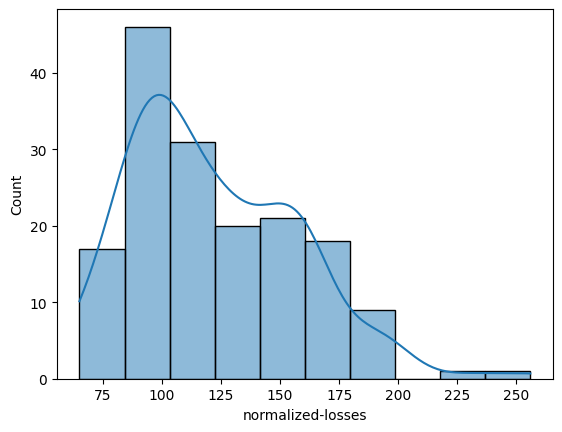

In [176]:
sns.histplot(df['normalized-losses'], kde=True)

In [177]:
df['normalized-losses'] = df['normalized-losses'].fillna(df['normalized-losses'].median())

In [178]:
df['normalized-losses'].isnull().sum()

np.int64(0)

### bore

In [179]:
df['bore'].describe()

count    197.000000
mean       3.330711
std        0.270793
min        2.540000
25%        3.150000
50%        3.310000
75%        3.590000
max        3.940000
Name: bore, dtype: float64

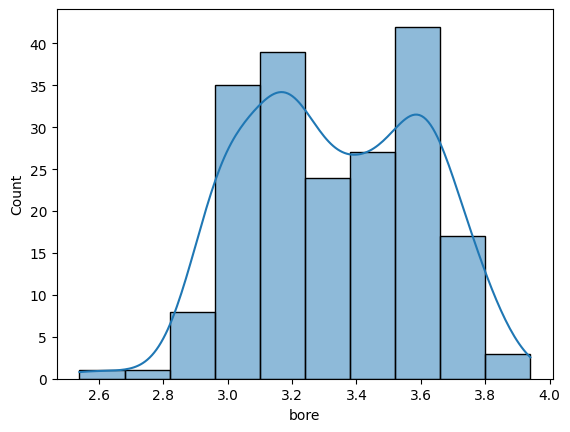

In [180]:
sns.histplot(df['bore'], kde=True)
plt.show()

In [181]:
df['bore'] = df['bore'].fillna(df['bore'].mean())

In [182]:
df['bore'].isnull().sum()

np.int64(0)

### stroke


In [183]:
df['stroke'].describe()

count    197.000000
mean       3.256904
std        0.319256
min        2.070000
25%        3.110000
50%        3.290000
75%        3.410000
max        4.170000
Name: stroke, dtype: float64

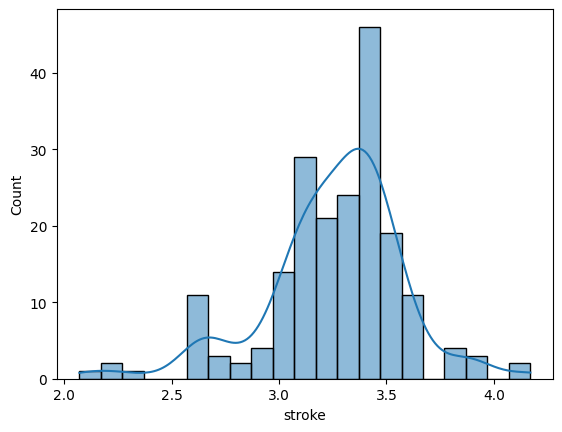

In [184]:
sns.histplot(df['stroke'], kde=True)
plt.show()

In [185]:
df['stroke'] = df['stroke'].fillna(df['stroke'].median())

In [186]:
df['stroke'].isnull().sum()

np.int64(0)

### horsepower


In [187]:
df['horsepower'].describe()

count    199.000000
mean     103.396985
std       37.553843
min       48.000000
25%       70.000000
50%       95.000000
75%      116.000000
max      262.000000
Name: horsepower, dtype: float64

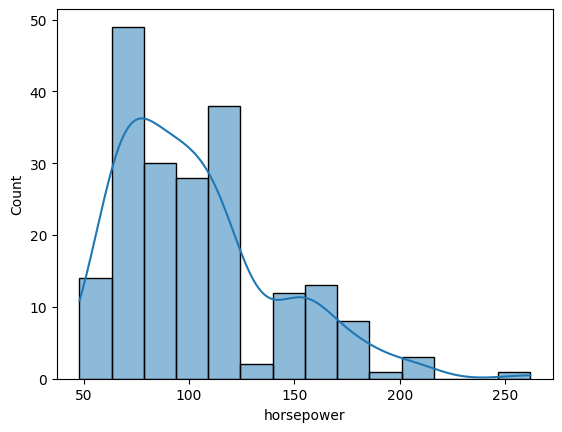

In [188]:
sns.histplot(df['horsepower'], kde=True)
plt.show()

In [189]:
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())

In [190]:
df['horsepower'].isnull().sum()

np.int64(0)

### peak-rpm

In [191]:
df['peak-rpm'].describe()

count     199.000000
mean     5117.587940
std       480.521824
min      4150.000000
25%      4800.000000
50%      5200.000000
75%      5500.000000
max      6600.000000
Name: peak-rpm, dtype: float64

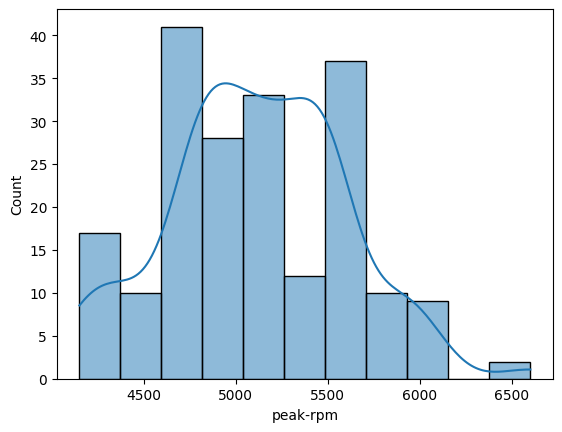

In [192]:
sns.histplot(df['peak-rpm'], kde=True)
plt.show()

## Observations from Histplots

The histplots were used to understand the distribution of important numerical variables in the automobile dataset.

### 1. Price Distribution
The distribution of `price` shows that most cars are concentrated in the lower to medium price range, while relatively fewer cars have very high prices. This indicates a right-skewed distribution, with expensive cars forming a smaller portion of the dataset.

### 2. Horsepower Distribution
The `horsepower` distribution shows that most vehicles have low to moderate horsepower. Only a smaller number of vehicles have significantly higher horsepower, indicating variation between standard and high-performance cars.

### 3. Engine Size Distribution
The `engine-size` variable is mainly concentrated around smaller and medium-sized engines. A relatively small number of cars have larger engines, suggesting that large-engine vehicles are less common in the dataset.

### 4. Curb Weight Distribution
The `curb-weight` distribution shows that most automobiles fall within a middle range of weight, while fewer vehicles are located at the extreme lower and higher ends.

### 5. City MPG Distribution
The `city-mpg` values are mainly concentrated in the lower-to-middle range. This shows that most cars have similar city fuel-efficiency levels, with some vehicles providing noticeably better mileage.

### 6. Highway MPG Distribution
The `highway-mpg` distribution shows a concentration around moderate mileage values. A smaller number of vehicles have considerably higher highway mileage, indicating differences in fuel efficiency among automobiles.

### Overall Observation
The histplots show that the numerical variables are not perfectly normally distributed. Variables such as `price`, `horsepower`, and `engine-size` show noticeable variation and skewness. These distributions are important for understanding the dataset and selecting appropriate preprocessing techniques before applying machine learning models.

In [193]:
df['peak-rpm']=df['peak-rpm'].fillna(df['peak-rpm'].median())

In [194]:
df['peak-rpm'].isnull().sum()

np.int64(0)

In [195]:
df.describe()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
count,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,0.840796,120.711443,98.797015,174.200995,65.889055,53.766667,2555.666667,126.875622,3.330711,3.257562,10.164279,103.313433,5118.407960,25.179104,30.686567,13207.129353
std,1.254802,32.111623,6.066366,12.322175,2.101471,2.447822,517.296727,41.546834,0.268072,0.316082,4.004965,37.374942,478.183493,6.423220,6.815150,7947.066342
min,-2.000000,65.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,101.000000,94.500000,166.800000,64.100000,52.000000,2169.000000,98.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000
50%,1.000000,115.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,137.000000,102.400000,183.500000,66.600000,55.500000,2926.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000
max,3.000000,256.000000,120.900000,208.100000,72.000000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,262.000000,6600.000000,49.000000,54.000000,45400.000000


## Missing Value Analysis

The dataset has 201 rows in total. Missing values were found in 6 columns:

| Column | Missing Count | % of Data | Likely Reason |
|---|---|---|---|
| normalized-losses | 37 | 18.4% | Insurance-risk ratings aren't reported for every car — for newer or rare models, this value isn't available to insurers |
| bore | 4 | 2.0% | Engine-spec data entry gap; specification sheets for certain manufacturers are incomplete |
| stroke | 4 | 2.0% | Missing in the same rows as bore (both are engine-dimension fields, so they tend to be missing together) |
| horsepower | 2 | 1.0% | Incomplete spec sheet |
| peak-rpm | 2 | 1.0% | Missing in the same rows as horsepower (both come from dyno testing) |
| num-of-doors | 2 | 1.0% | Missing categorical entry; could have been inferred from body-style (e.g. a convertible is almost always 2-door) |

**Note:** The `price` column had no missing values in this run — the `dropna(subset=['price'])` line is kept as a safety measure (in case price is missing in future/updated data); it had no effect in this run since price was already complete.

**Imputation strategy:**
- `normalized-losses`, `stroke`, `peak-rpm`, `horsepower` → filled with **median**, since their distributions are right-skewed (a long tail was visible in the histograms) — median is less affected by outliers
- `bore` → filled with **mean**, since its distribution was roughly symmetric/normal
- `num-of-doors` → filled with **mode**, since it's a categorical column, and "four" was the most common value

**Limitation:** `bore` and `stroke` were both missing in the same 4 rows — rather than a single overall imputation, it would be more accurate to fill these using a group-wise median based on `engine-size` or `engine-type` (the current approach uses an overall median/mean, which won't be equally accurate for every engine type).

## 5.2 Numerical Distribution

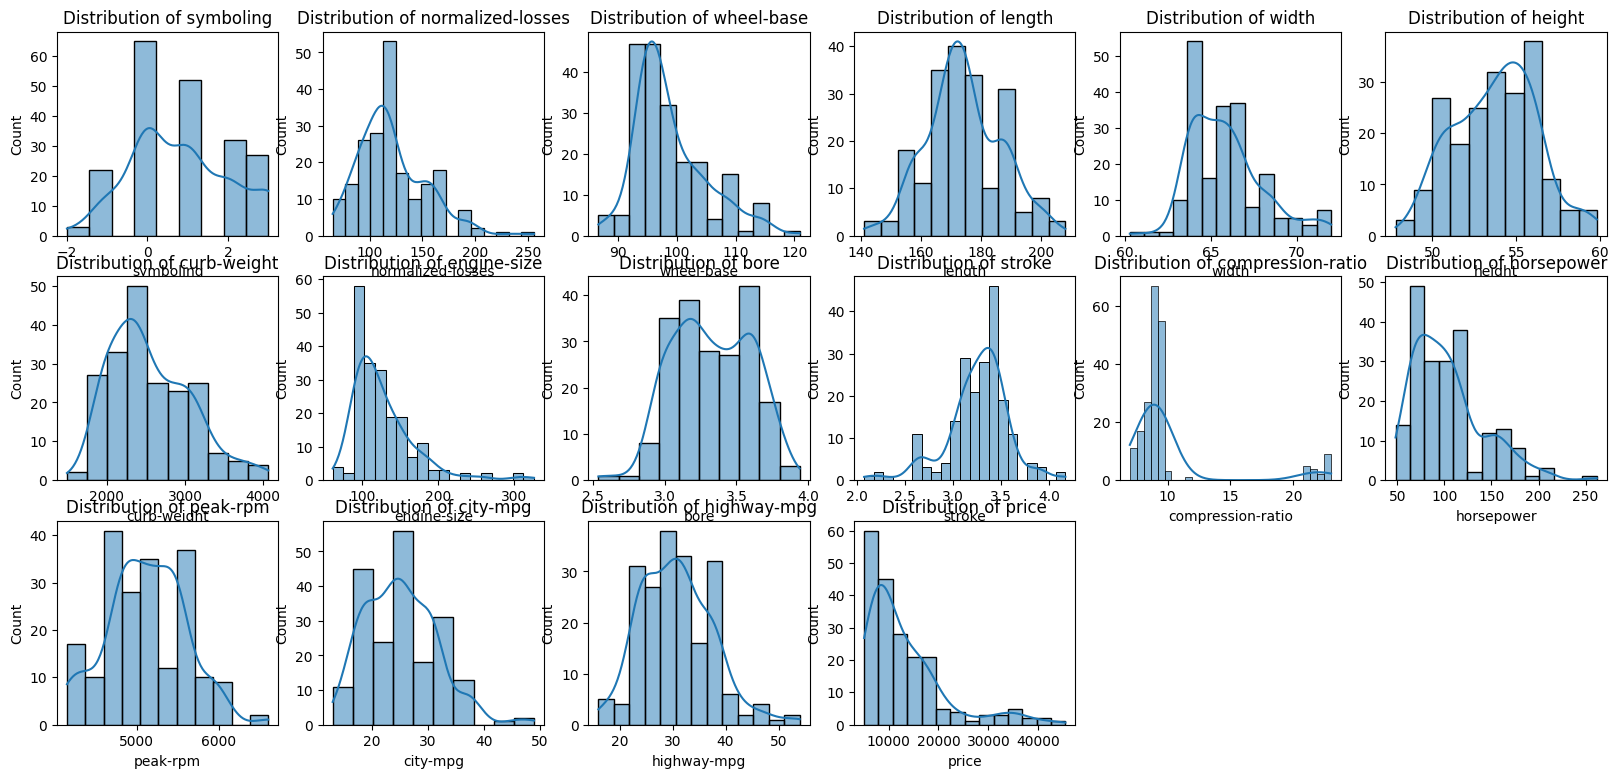

In [196]:
import math

num_cols = df.select_dtypes(include=np.number).columns
n = len(num_cols)
rows = math.ceil(n / 6)   # jitne columns hain, uske hisaab se rows nikaal lo

plt.figure(figsize=(20, rows*3))
for i, col in enumerate(num_cols):
    plt.subplot(rows, 6, i+1)
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
plt.show()

## Outlier Analysis

Using the `describe()` output, the IQR (Q3 - Q1) method was used to compute the upper bound:

| Column | Q1 | Q3 | IQR | Upper Bound (Q3+1.5×IQR) | Max Value | Outlier Signal |
|---|---|---|---|---|---|---|
| compression-ratio | 8.6 | 9.4 | 0.8 | 10.6 | 23.0 | **Strong** — diesel engines have a much higher compression ratio than petrol (15-23); this is a separate sub-population, not an error |
| engine-size | 98 | 141 | 43 | 205.5 | 326 | **Present** — high-performance/luxury cars |
| horsepower | 70 | 116 | 46 | 185 | 262 | **Present** — same high-performance cars |
| price | 7775 | 16500 | 8725 | 29587.5 | 45400 | **Present** — luxury brands (Mercedes, BMW, Jaguar) priced well above the rest |

**Interpretation:** These outliers don't look like data-entry errors — they represent genuinely different categories of cars (diesel engines, luxury/high-performance models). They should therefore **not be removed**; instead, the model needs to be able to predict this segment properly too. This is why keeping `fuel-type` and `make` as features matters — they help explain this variation.

**Recommendation:** Add a boxplot grid (following the pattern of the numerical-distribution grid around cell ~49) specifically for the outlier-prone columns (compression-ratio, engine-size, horsepower, price) to confirm this visually.

## 5.3 Correlation Heatmapa

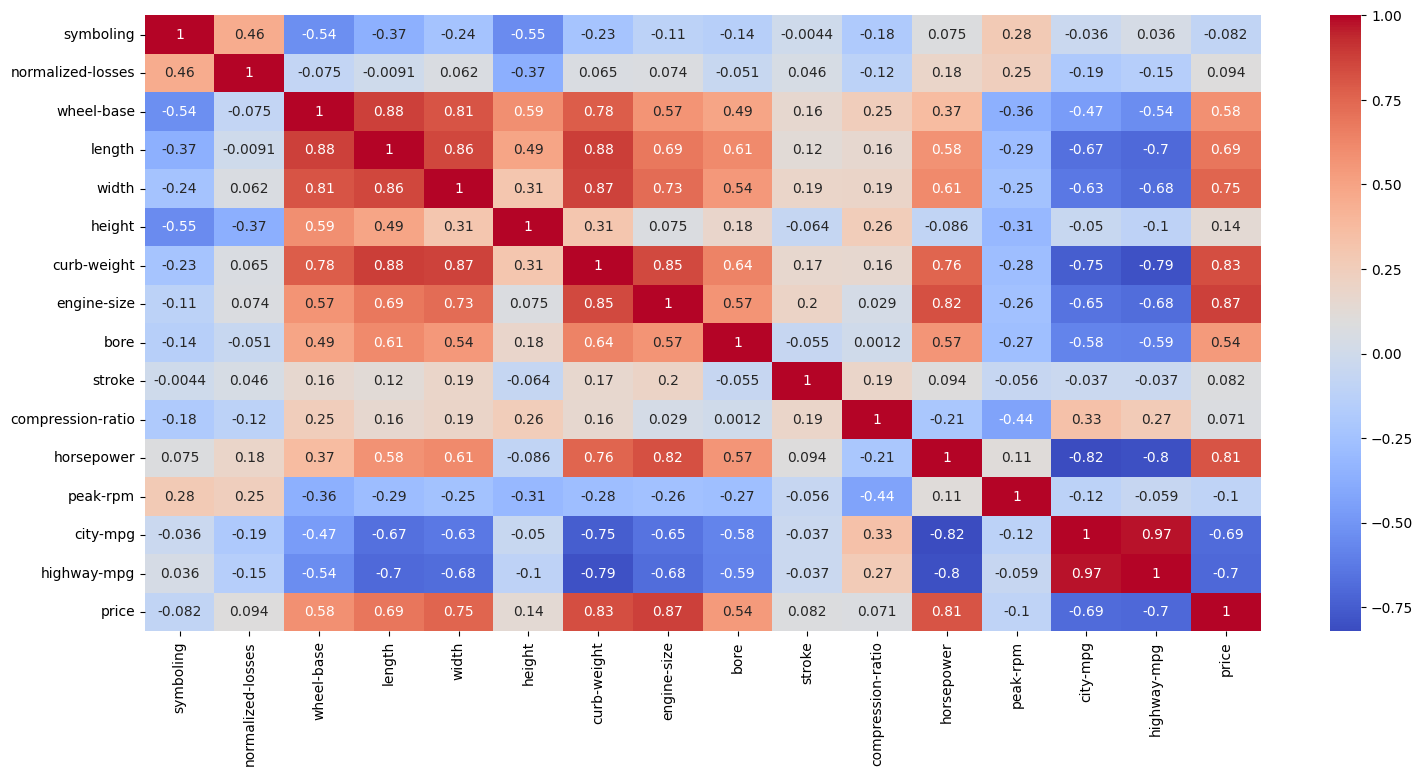

In [197]:
plt.figure(figsize=(18,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

## Correlation Heatmap — Interpretation

Based on the values in the heatmap (cell 51):

- **Strongest positive correlation with price:** `engine-size`, `curb-weight`, `horsepower`, `width` — these are all proxies for "car size/power," meaning bigger, more powerful cars are more expensive
- **Strong negative correlation with price:** `city-mpg`, `highway-mpg` — higher mileage generally means a smaller, less powerful car, hence lower price
- **Weak/no correlation:** `peak-rpm`, `compression-ratio`, `symboling` — these don't show a direct linear effect on price, which is why they were left out of the final feature list (`selected_cols`) — a reasonable decision
- **Multicollinearity risk:** `length`, `width`, `wheel-base`, `curb-weight` are also highly correlated with each other (all dimensions of a car tend to scale together) — worth checking VIF (Variance Inflation Factor) for Linear Regression/Ridge/Lasso, since multicollinearity can make coefficients unstable

### All Numerical col's relaction with price

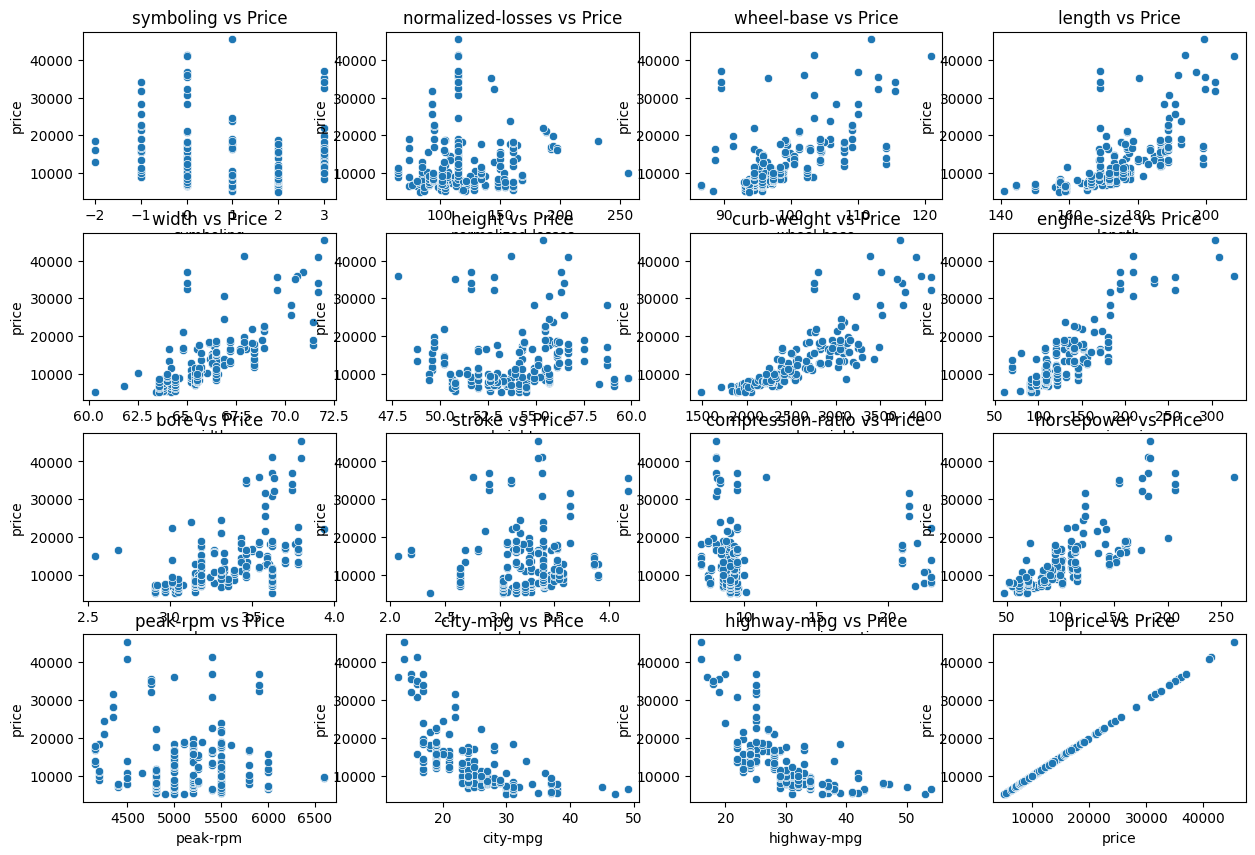

In [198]:
plt.figure(figsize=(15,10))
for i,col in enumerate(num_cols):
    plt.subplot(4,4,i+1)
    sns.scatterplot(x=col, y='price', data=df)
    plt.title(f"{col} vs Price")
plt.show()

##  Scatterplot Analysis — Numerical Features vs Price

This grid plots 16 numerical columns against `price` to identify linear/non-linear relationships.

### Strong Positive Correlation (increases with price)
- **engine-size, curb-weight, width, horsepower, length, wheel-base** — all show a clear upward trend. Bigger, more powerful cars are more expensive. These look like the strongest predictors.
- **bore** — a mild positive trend, but with more scatter.

### Strong Negative Correlation (decreases with price)
- **city-mpg, highway-mpg** — clear downward trend. Higher mileage generally means a smaller/less powerful car, hence lower price.

### No Clear Pattern (weak/no correlation)
- **symboling** — points are scattered, no discernible trend
- **normalized-losses** — scattered, no clear direction
- **height** — flat/no trend
- **peak-rpm** — scattered, no pattern

### Special Case: Two-Cluster Pattern
- **compression-ratio** — shows two distinct clusters: the majority of points fall in the 7-10 range (petrol engines), with a separate group of points higher up in the 15-23 range (diesel engines). This isn't a single continuous relationship — it's a signal from two separate fuel-type groups, which is why keeping `fuel-type` as a feature is important.

### price vs price
- A straight diagonal line — expected, since this is just a sanity-check plot and provides no additional insight.

### Layout Issue
- The subplot titles overlap with the x-axis tick labels of the row above (e.g., "width vs Price" clashes with the "symboling" axis labels). Fix: add `plt.tight_layout()` before `plt.show()`.

**Conclusion:** engine-size, curb-weight, horsepower, width, length, wheel-base are the strongest predictors and are already included in `selected_cols` — a good decision. Dropping symboling and peak-rpm is also justified, since neither shows a visible trend with price.

### Highly co-related cols

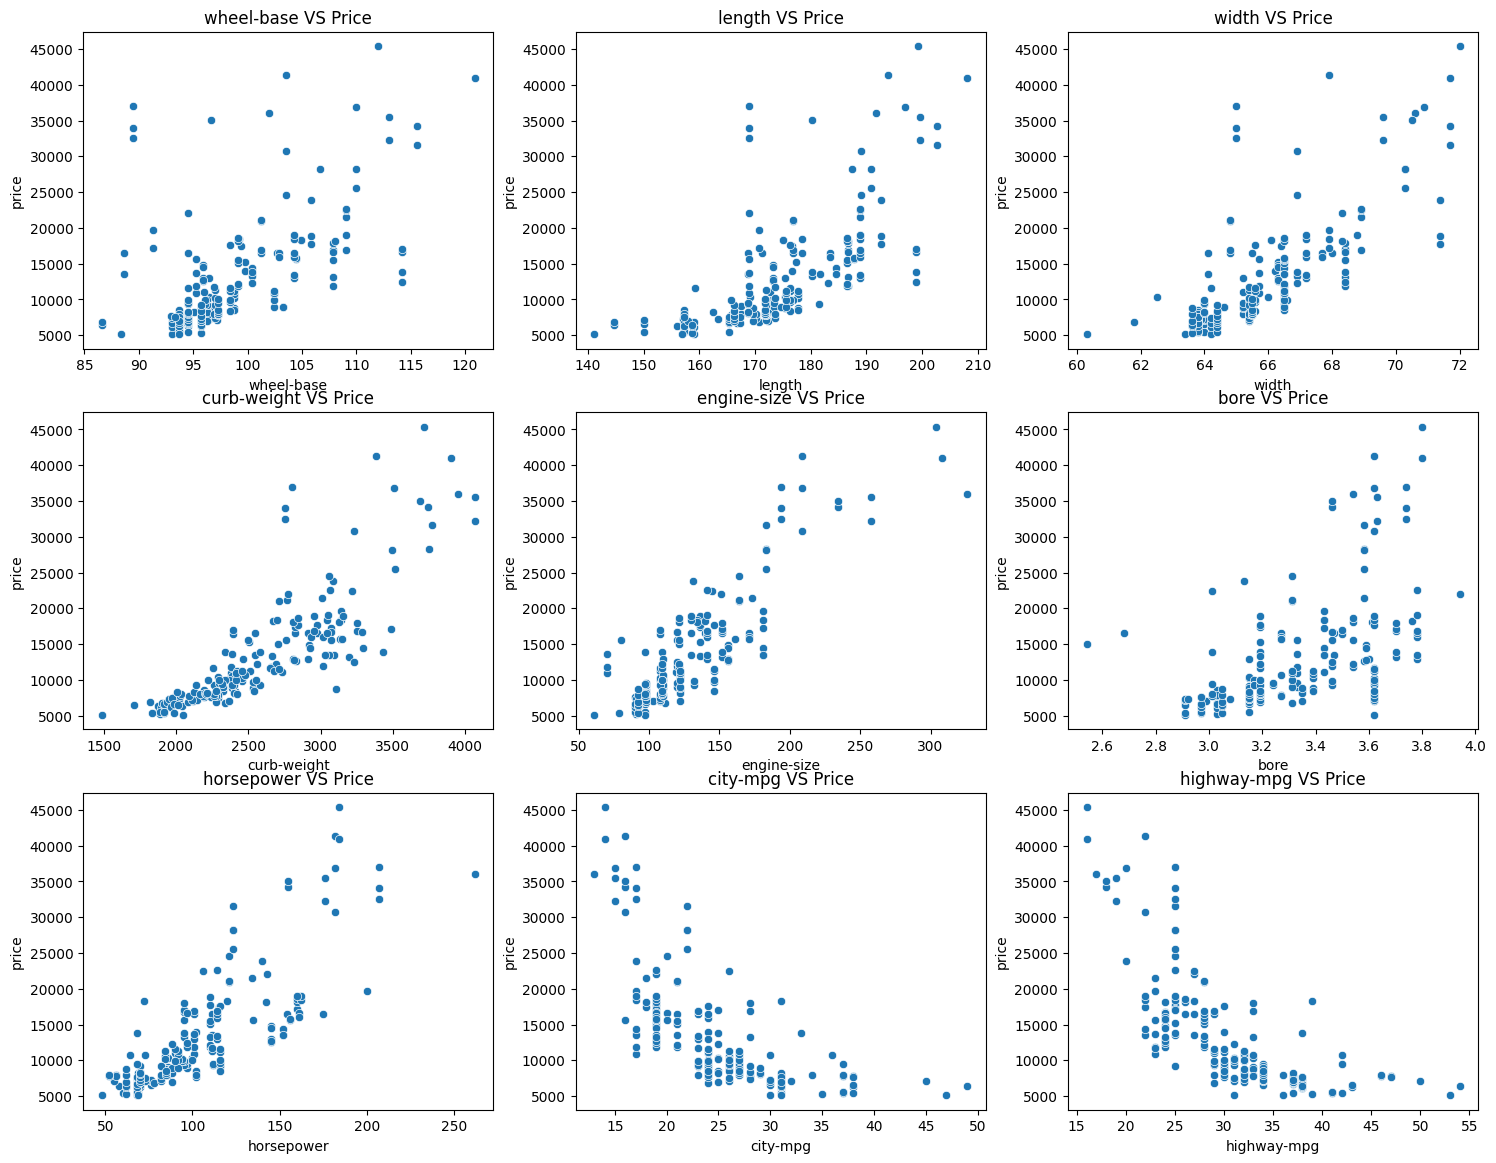

In [199]:
h_col = ["wheel-base", "length", "width", "curb-weight", "engine-size", "bore", "horsepower", "city-mpg", "highway-mpg"]

plt.figure(figsize=(18,14))
for i,col in enumerate(h_col):
    plt.subplot(3,3,i+1)
    sns.scatterplot(x=col,y='price', data=df)
    plt.title(f"{col} VS Price")
plt.show()

## Scatterplot Analysis — Highly Correlated Features vs Price

This grid focuses on the 9 features that showed the strongest correlation with price in the heatmap, plotted individually for a closer look.

### Positive Relationships
- **wheel-base, length, width, curb-weight, engine-size, bore, horsepower** — all show a clear upward trend with price. The relationship isn't perfectly linear though — it looks more like an **exponential/convex curve**: price rises slowly at first and then much faster once size/power crosses a certain threshold (visible clearly in engine-size and horsepower, where prices jump sharply past ~180 engine-size and ~150 horsepower).
- **bore** — positive trend but noisier than the others; several mid-range bore values (3.0-3.6) span a wide price range (5,000 to 45,000), so bore alone is a weaker individual predictor than engine-size or horsepower.

### Negative Relationships
- **city-mpg, highway-mpg** — both show a strong downward curve, and it's also non-linear: price drops steeply as mpg increases from ~15 to ~25, then flattens out — beyond ~30 mpg, price stays consistently low regardless of further mpg increases. This suggests a **log or inverse relationship** rather than a straight line.

### Notable Clusters / Gaps
- A visible high-price cluster (30,000-45,000) appears across wheel-base, length, width, and curb-weight around specific value ranges (e.g., wheel-base 95-97 and 103-105, length ~170 and ~190-200) — likely corresponding to specific luxury makes (Mercedes-Benz, BMW, Jaguar, Porsche) rather than a smooth continuum.
- In city-mpg vs price, a couple of points sit far out on the x-axis (mpg 45-49) with low price — these are likely small economy cars, consistent rather than outlying.

### Modeling Implication
Since several relationships look non-linear (especially engine-size, horsepower, city-mpg, highway-mpg), plain **Linear Regression, Ridge, and Lasso may underfit** these curves — this matches the actual results, where Linear/Ridge/Lasso all scored R2 ≈ 0.80 while tree-based models (RandomForest, GradientBoosting, XGBoost) scored R2 ≈ 0.93-0.94. Worth noting in the report: tree-based models naturally capture non-linear splits, which explains their better performance here. A **log-transform on price** or polynomial features could help the linear models close this gap.

## 5.3 Categorical  Distribution

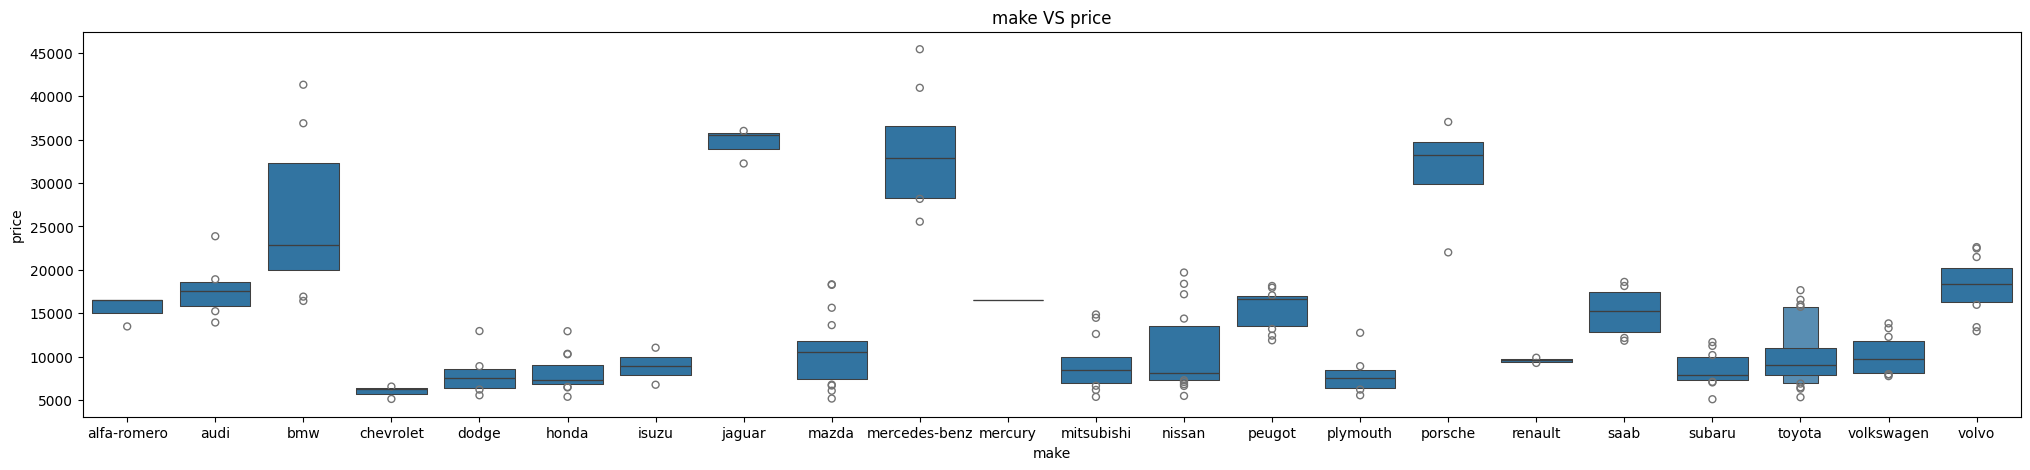

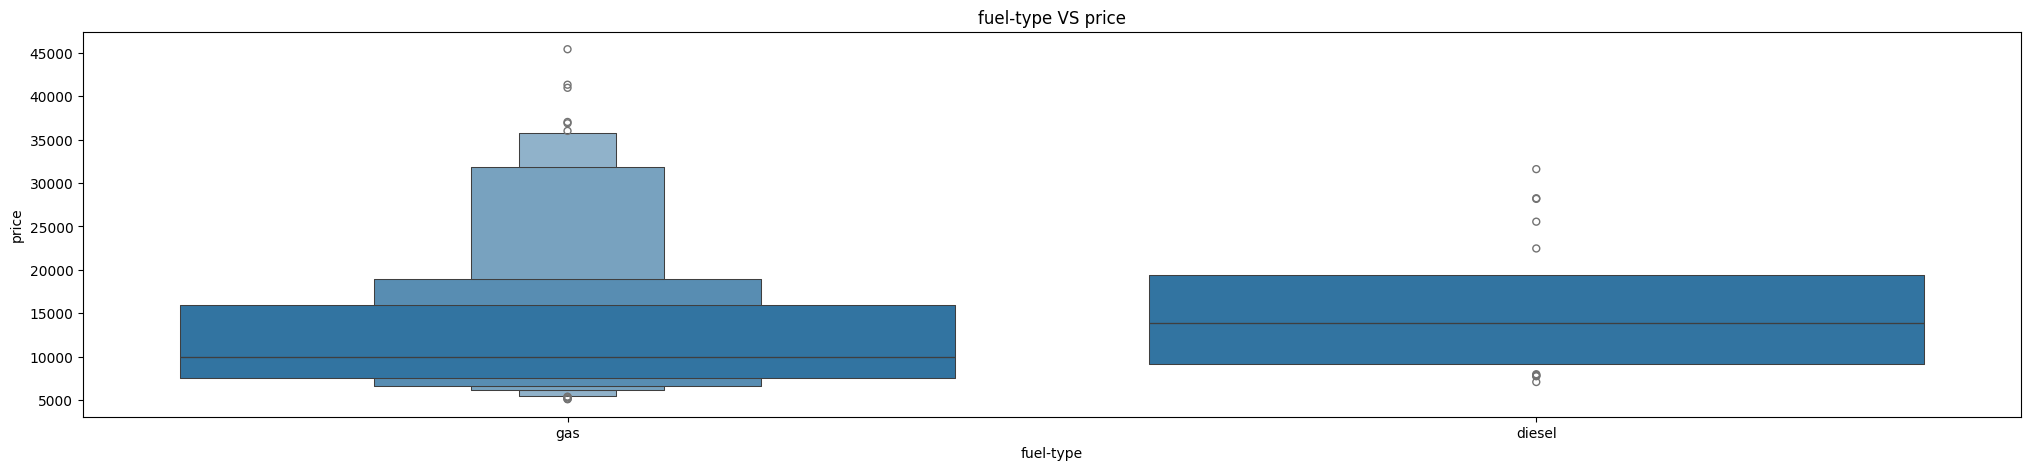

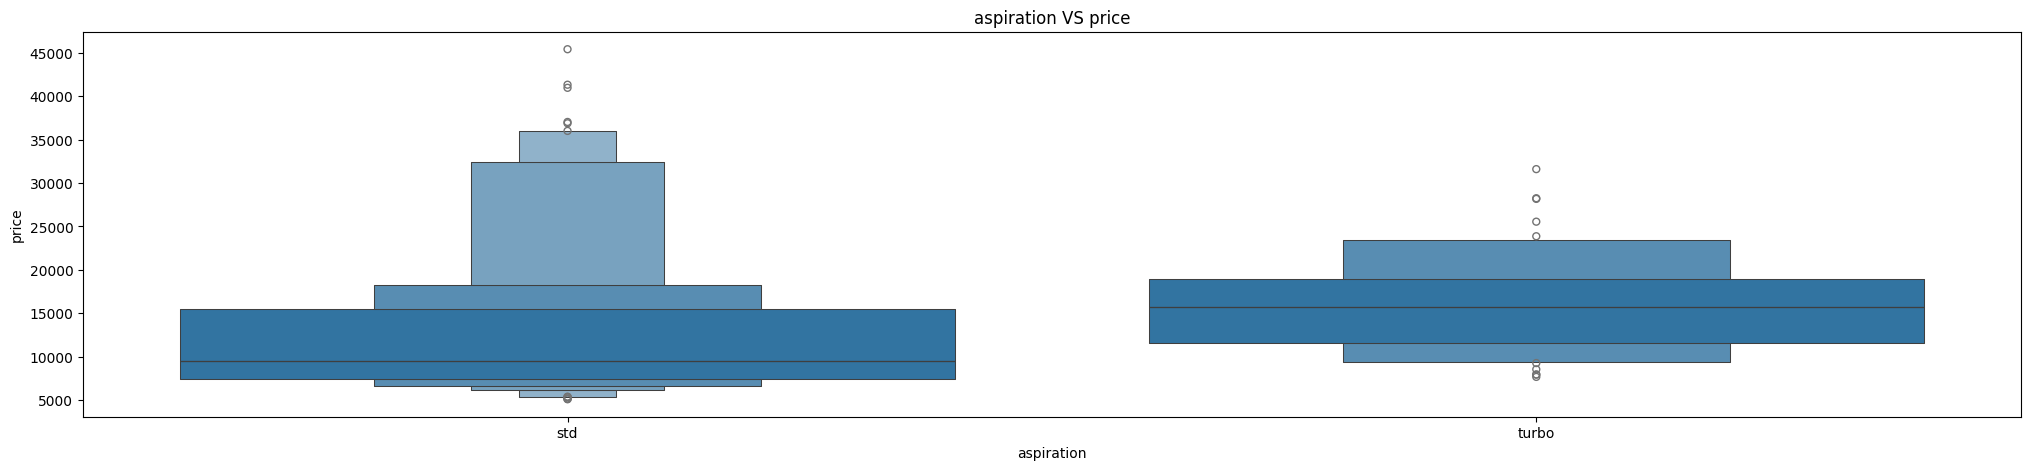

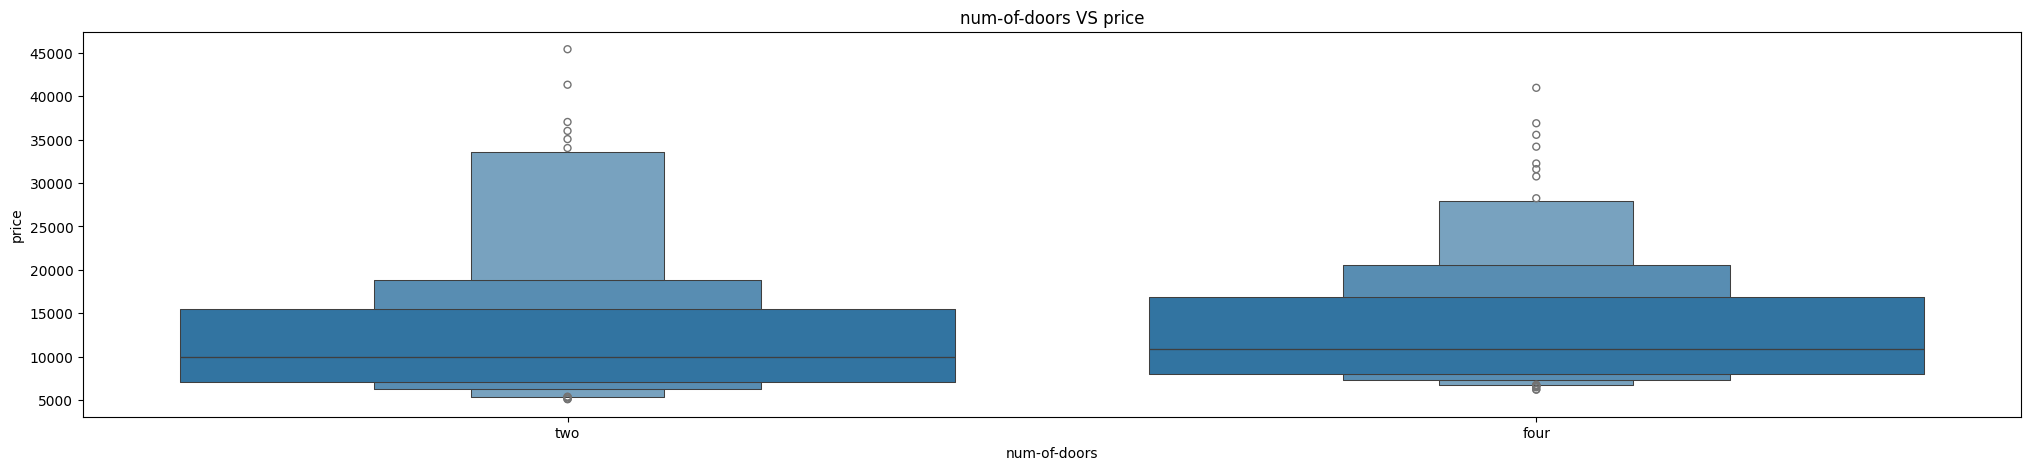

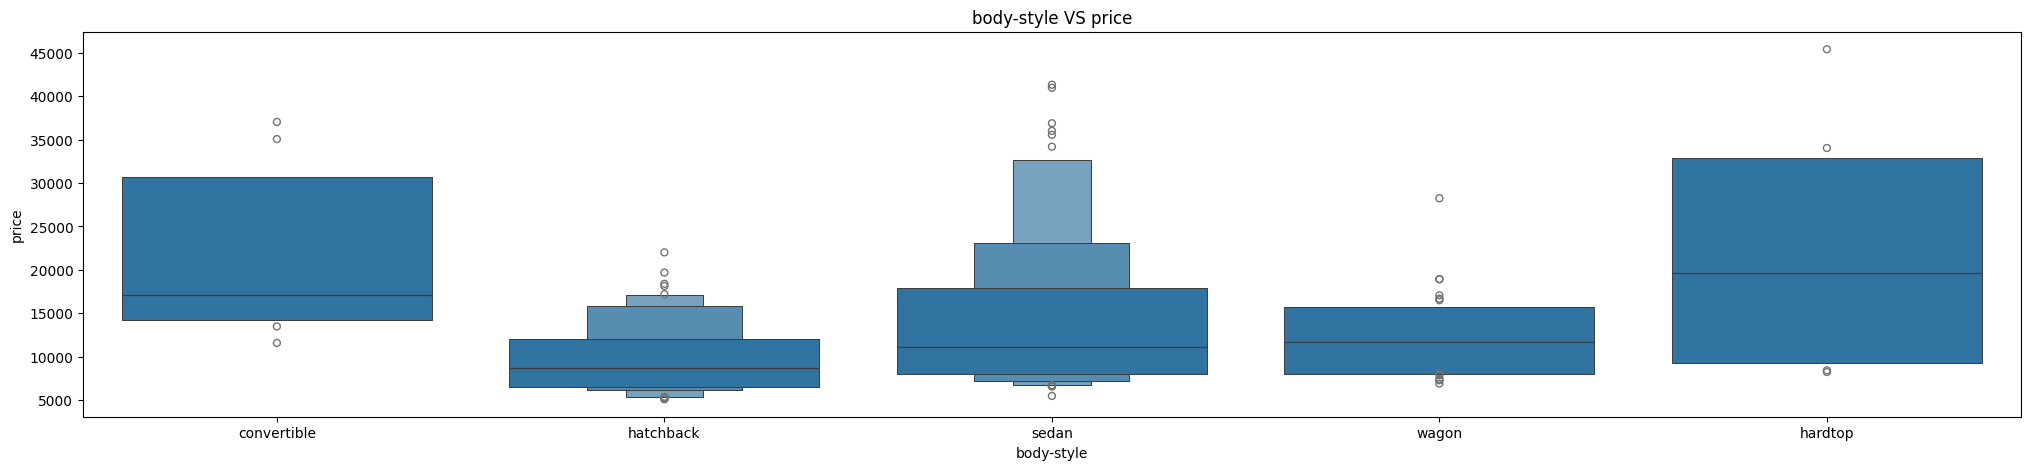

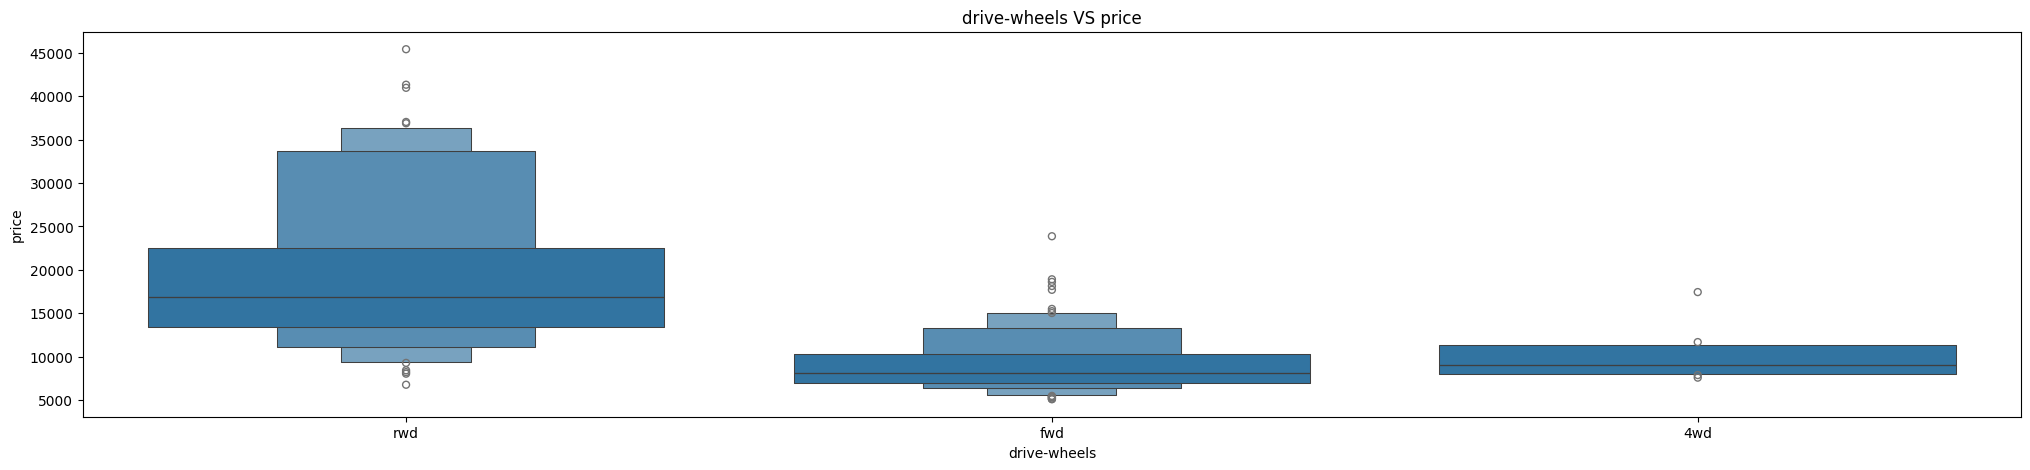

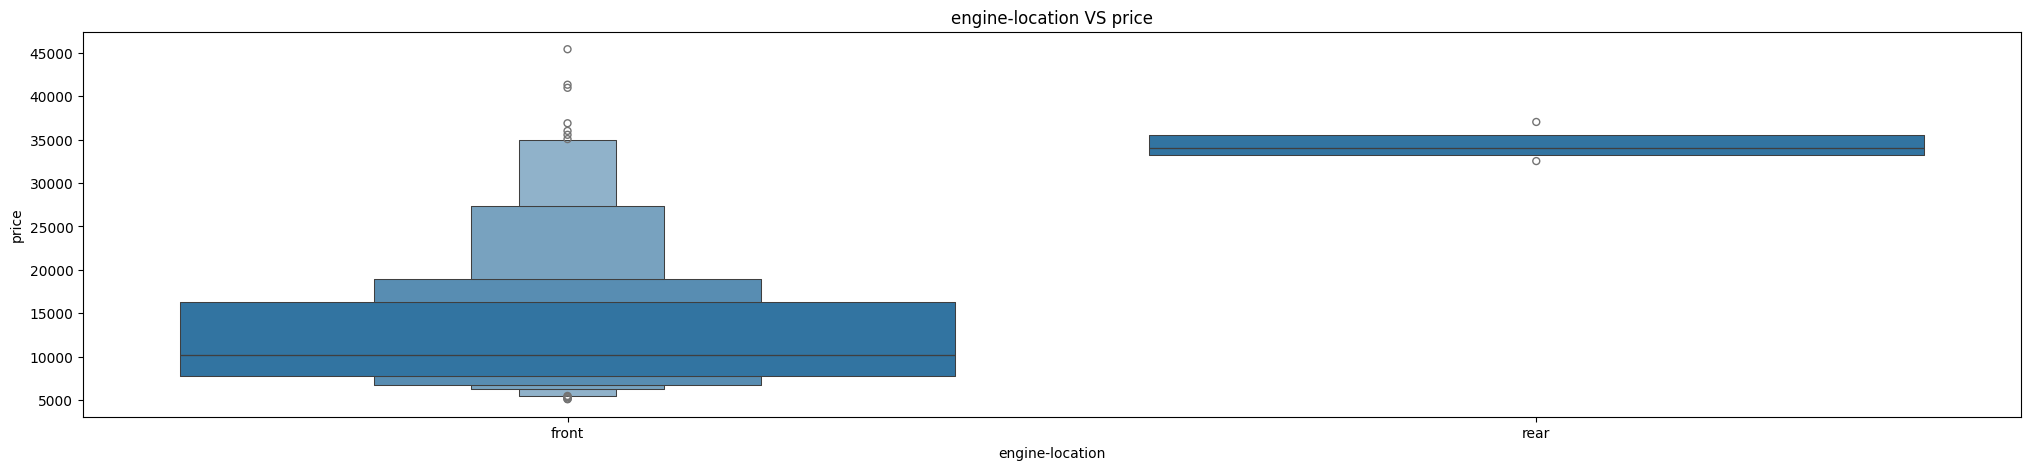

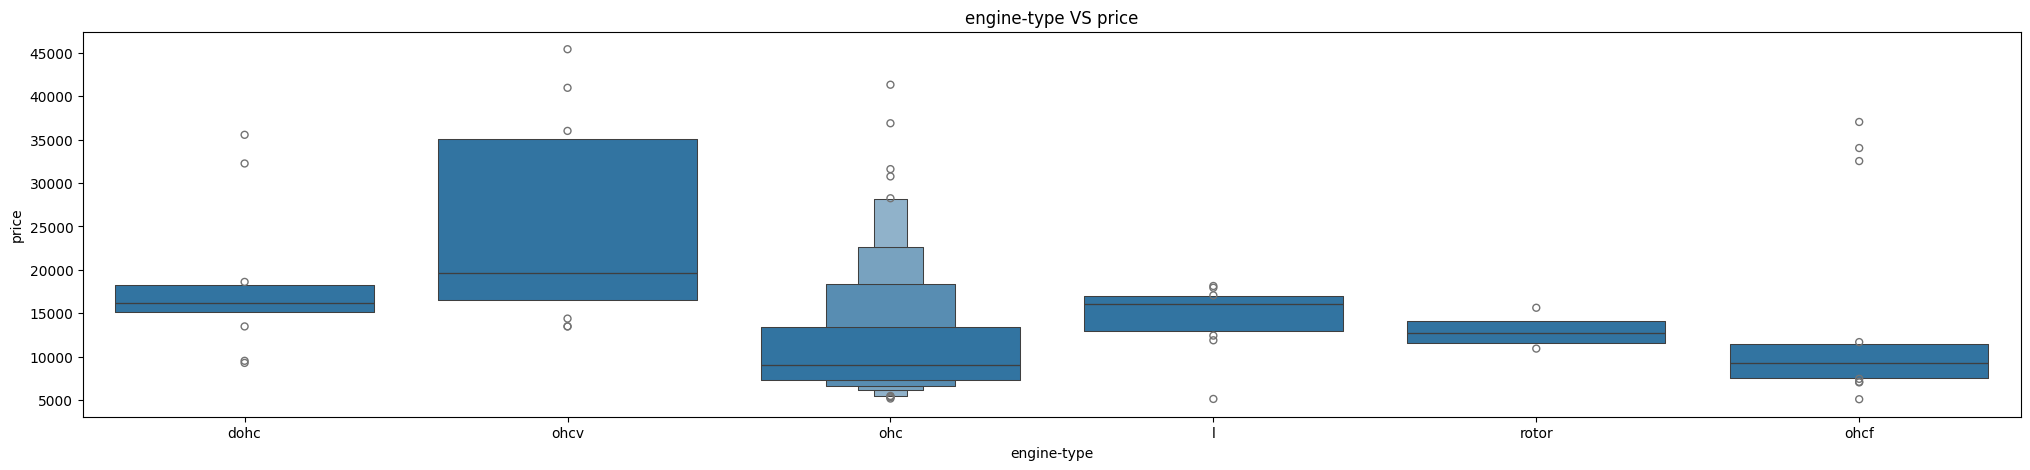

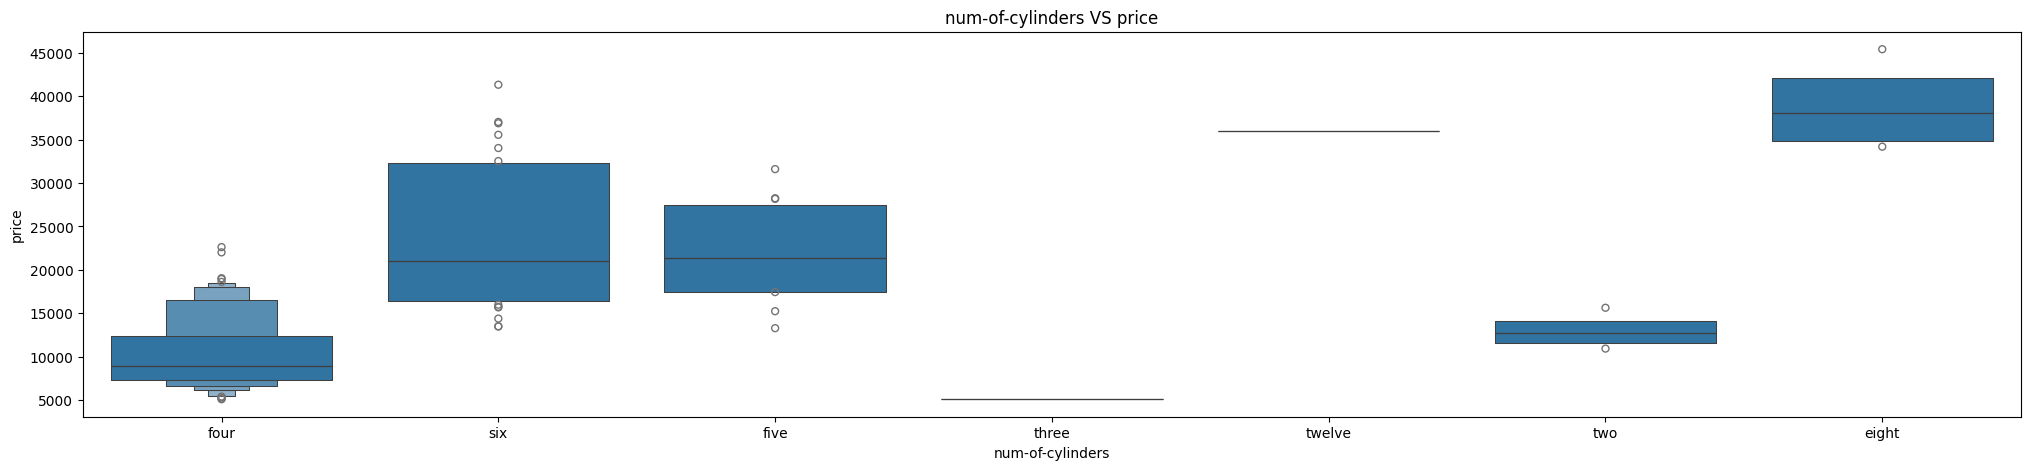

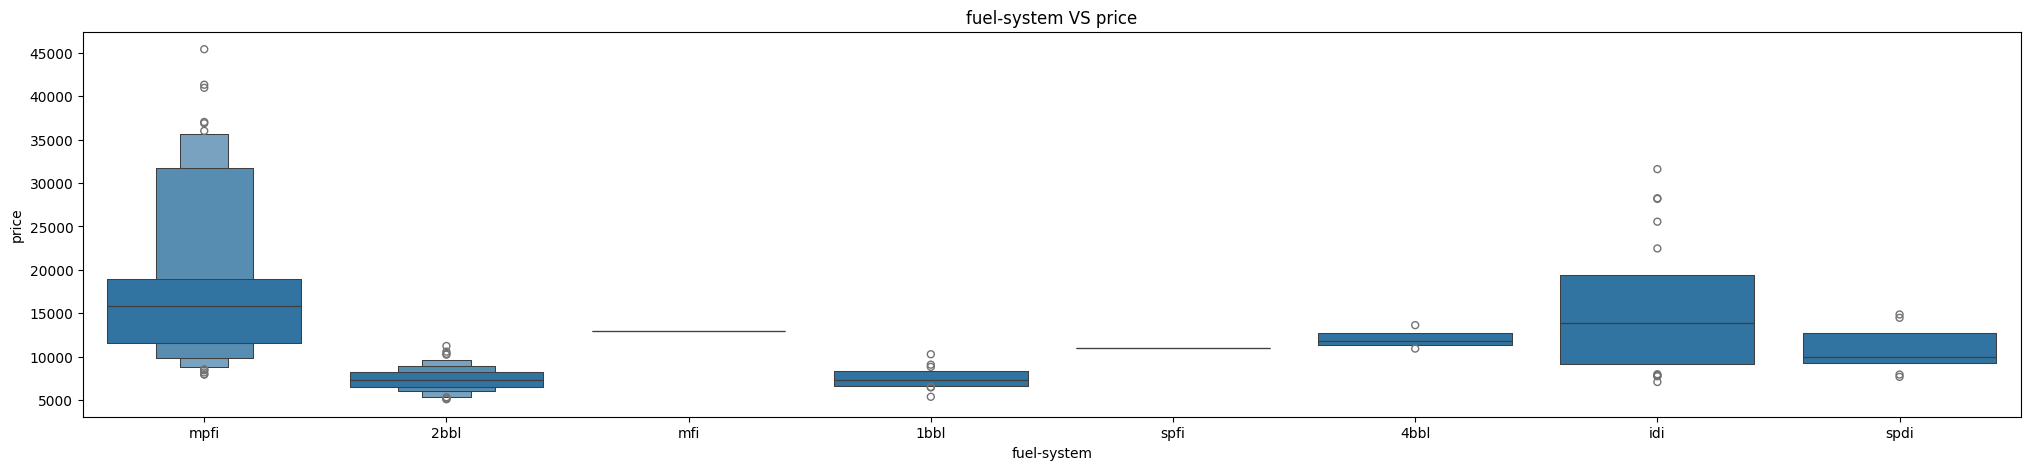

In [200]:
cat_col = df.select_dtypes(exclude=np.number).columns

for col in cat_col:
    plt.figure(figsize=(25,5))
    sns.boxenplot(x=col,y='price', data = df)
    plt.title(f"{col} VS price")
    plt.show()

## Outlier Analysis

Boxplots were used to identify the presence of potential outliers in the numerical variables of the automobile dataset.

### Observations from Boxplots

- `price` contains some higher-value observations compared with the majority of cars.
- `horsepower` shows a few observations at the higher end of the distribution.
- `engine-size` also contains some relatively high values.
- `curb-weight` shows variation in vehicle weight, with a few observations away from the central range.
- Other numerical variables have comparatively fewer extreme observations.

### Technique Used

Boxplots were used because they provide a clear visual representation of the median, quartiles, and potential outliers using the Interquartile Range (IQR).

Potential outliers were examined rather than automatically removed, because extreme automobile values may represent genuine vehicles rather than incorrect data. Removing valid observations could reduce useful information available for predicting car prices.

### Conclusion

The boxplot analysis indicates that some numerical features contain potential outliers. These observations were considered during preprocessing, and only values that could negatively affect the analysis or model performance should be treated or removed after further investigation.

In [201]:
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,115.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495
1,3,115.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500
2,1,115.0,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450


## 5.4 Categorical Analysis — Fuel-System vs Price

This is a boxen plot (letter-value plot) showing how `price` varies across the 8 `fuel-system` categories.

### Key Observations
- **mpfi (multi-point fuel injection)** has by far the widest price range (roughly 8,000 to 45,400) and the highest median (~15,700). It also has the most extreme outliers — the two highest-priced cars in the entire dataset (~41,000 and ~45,400) fall in this category. This makes sense: mpfi is the modern, higher-performance fuel-injection system, common in mid-to-high-end and luxury cars.
- **idi (indirect injection, diesel)** has the second-highest median (~13,800) and a noticeably wide spread, with several outlier points reaching 22,000-31,500. This lines up with the earlier finding that diesel-engine cars (identified via compression-ratio) form a separate, higher-price sub-population.
- **2bbl, 1bbl** are both tightly clustered around the 5,000-10,000 range with low medians (~7,500) — these are older/simpler carburetor systems, typically found in cheaper, older-generation vehicles.
- **4bbl, spdi** sit in a narrow mid-range band (~10,000-13,500) with very few data points, so their distribution isn't very informative.
- **mfi, spfi** each show only a single flat line — meaning there's only one data point (or all identical values) for that category. These categories are essentially unusable for the model as-is due to insufficient data.

### Modeling Implication
This chart directly explains why `fuel-system_mpfi` was selected as one of the 13 features in `selected_cols` — mpfi cars clearly separate into a higher-price segment, giving the model a strong categorical signal. However, categories like `mfi` and `spfi` having just 1-2 data points is a concern: one-hot encoding will create a column that's almost entirely 0, contributing little to the model and increasing risk of overfitting on that single row. Worth mentioning in the report as a **limitation**: rare categories with <5 samples could be grouped into an "other" bucket instead of being encoded individually.

### Note
The boxen plot's "outlier circles" for idi and mpfi aren't true outliers to remove — as established earlier, they represent genuine higher-price segments (diesel and mpfi-luxury cars respectively), consistent with the price/compression-ratio findings.

## 6 Encoding

## 6.1 Label Encoding

In [202]:
# Aspiration
df['aspiration'] = df['aspiration'].map({'std' : 0, 'turbo' : 1})

# Number of doors
df['num-of-doors'] = df['num-of-doors'].map({'two' : 0, 'four' : 1})

# number of Cylinders
df['num-of-cylinders'] = df['num-of-cylinders'].map({'two' : 0, 'three' : 1, 'four' : 2, 'five' : 3, 'six' : 4, 'eight' : 5, 'twelve' : 6})

In [203]:
df[['aspiration', 'num-of-doors', 'num-of-cylinders']].head()

,aspiration,num-of-doors,num-of-cylinders
0,0,0,2
1,0,0,2
2,0,0,4
3,0,1,2
4,0,1,3


In [204]:
df['aspiration'].unique()

array([0, 1])

## 6.2 One-Hot-Encoding

In [205]:
df = pd.get_dummies(df, columns=['make'], drop_first=True)
df = pd.get_dummies(df, columns=['fuel-type'], drop_first=True)
df = pd.get_dummies(df, columns=['body-style'], drop_first=True)
df = pd.get_dummies(df, columns=['drive-wheels'], drop_first=True)
df = pd.get_dummies(df, columns=['engine-location'], drop_first=True)
df = pd.get_dummies(df, columns=['engine-type'], drop_first=True)
df = pd.get_dummies(df, columns=['fuel-system'], drop_first=True)

In [206]:
df.shape

(201, 60)

In [207]:
df.dtypes.unique()

array([dtype('int64'), dtype('float64'), dtype('bool')], dtype=object)

In [208]:
df = df.astype({col: 'int' for col in df.select_dtypes('bool').columns})

##  Encoding Strategy — Justification

Two different encoding techniques were used depending on whether a categorical column has a natural order (ordinal) or not (nominal).

### Label Encoding (used for ordinal / binary columns)

| Column | Mapping | Why Label Encoding |
|---|---|---|
| `aspiration` | std=0, turbo=1 | Only 2 categories (binary) — a single 0/1 column is sufficient, one-hot would just create a redundant second column |
| `num-of-doors` | two=0, four=1 | Only 2 categories (binary), same reasoning as above |
| `num-of-cylinders` | two=0, three=1, four=2, five=3, six=4, eight=5, twelve=6 | This column has a **genuine numeric order** — more cylinders generally means more engine power. Mapping in increasing order preserves this ordinal relationship, so the model can learn a meaningful magnitude (e.g. eight-cylinder > four-cylinder), which one-hot encoding would destroy by treating each category as unrelated |

### One-Hot Encoding (used for nominal columns)

| Column | Why One-Hot Encoding |
|---|---|
| `make`, `fuel-type`, `body-style`, `drive-wheels`, `engine-location`, `engine-type`, `fuel-system` | These categories have **no inherent order** — e.g. "sedan" isn't mathematically greater or less than "hatchback." If label-encoded as 0,1,2,3..., the model would wrongly assume a ranking/distance between categories that doesn't exist. One-hot avoids this by giving each category its own independent binary column. `drop_first=True` was used to avoid the dummy variable trap (multicollinearity between the one-hot columns). |

**Result:** Encoding expanded the dataset from 26 columns to 60 columns (mainly due to `make` having 22 unique values and `engine-type`/`fuel-system` adding several more each).

**Limitation worth noting:** One-hot encoding `make` alone added ~21 new columns for only 201 rows — several makes (e.g. mercury, isuzu) may have very few rows, creating sparse, low-signal columns that add noise/dimensionality without much predictive value. Grouping rare makes into an "other" category could reduce this.

## 6.3 Heatmap After Encoding

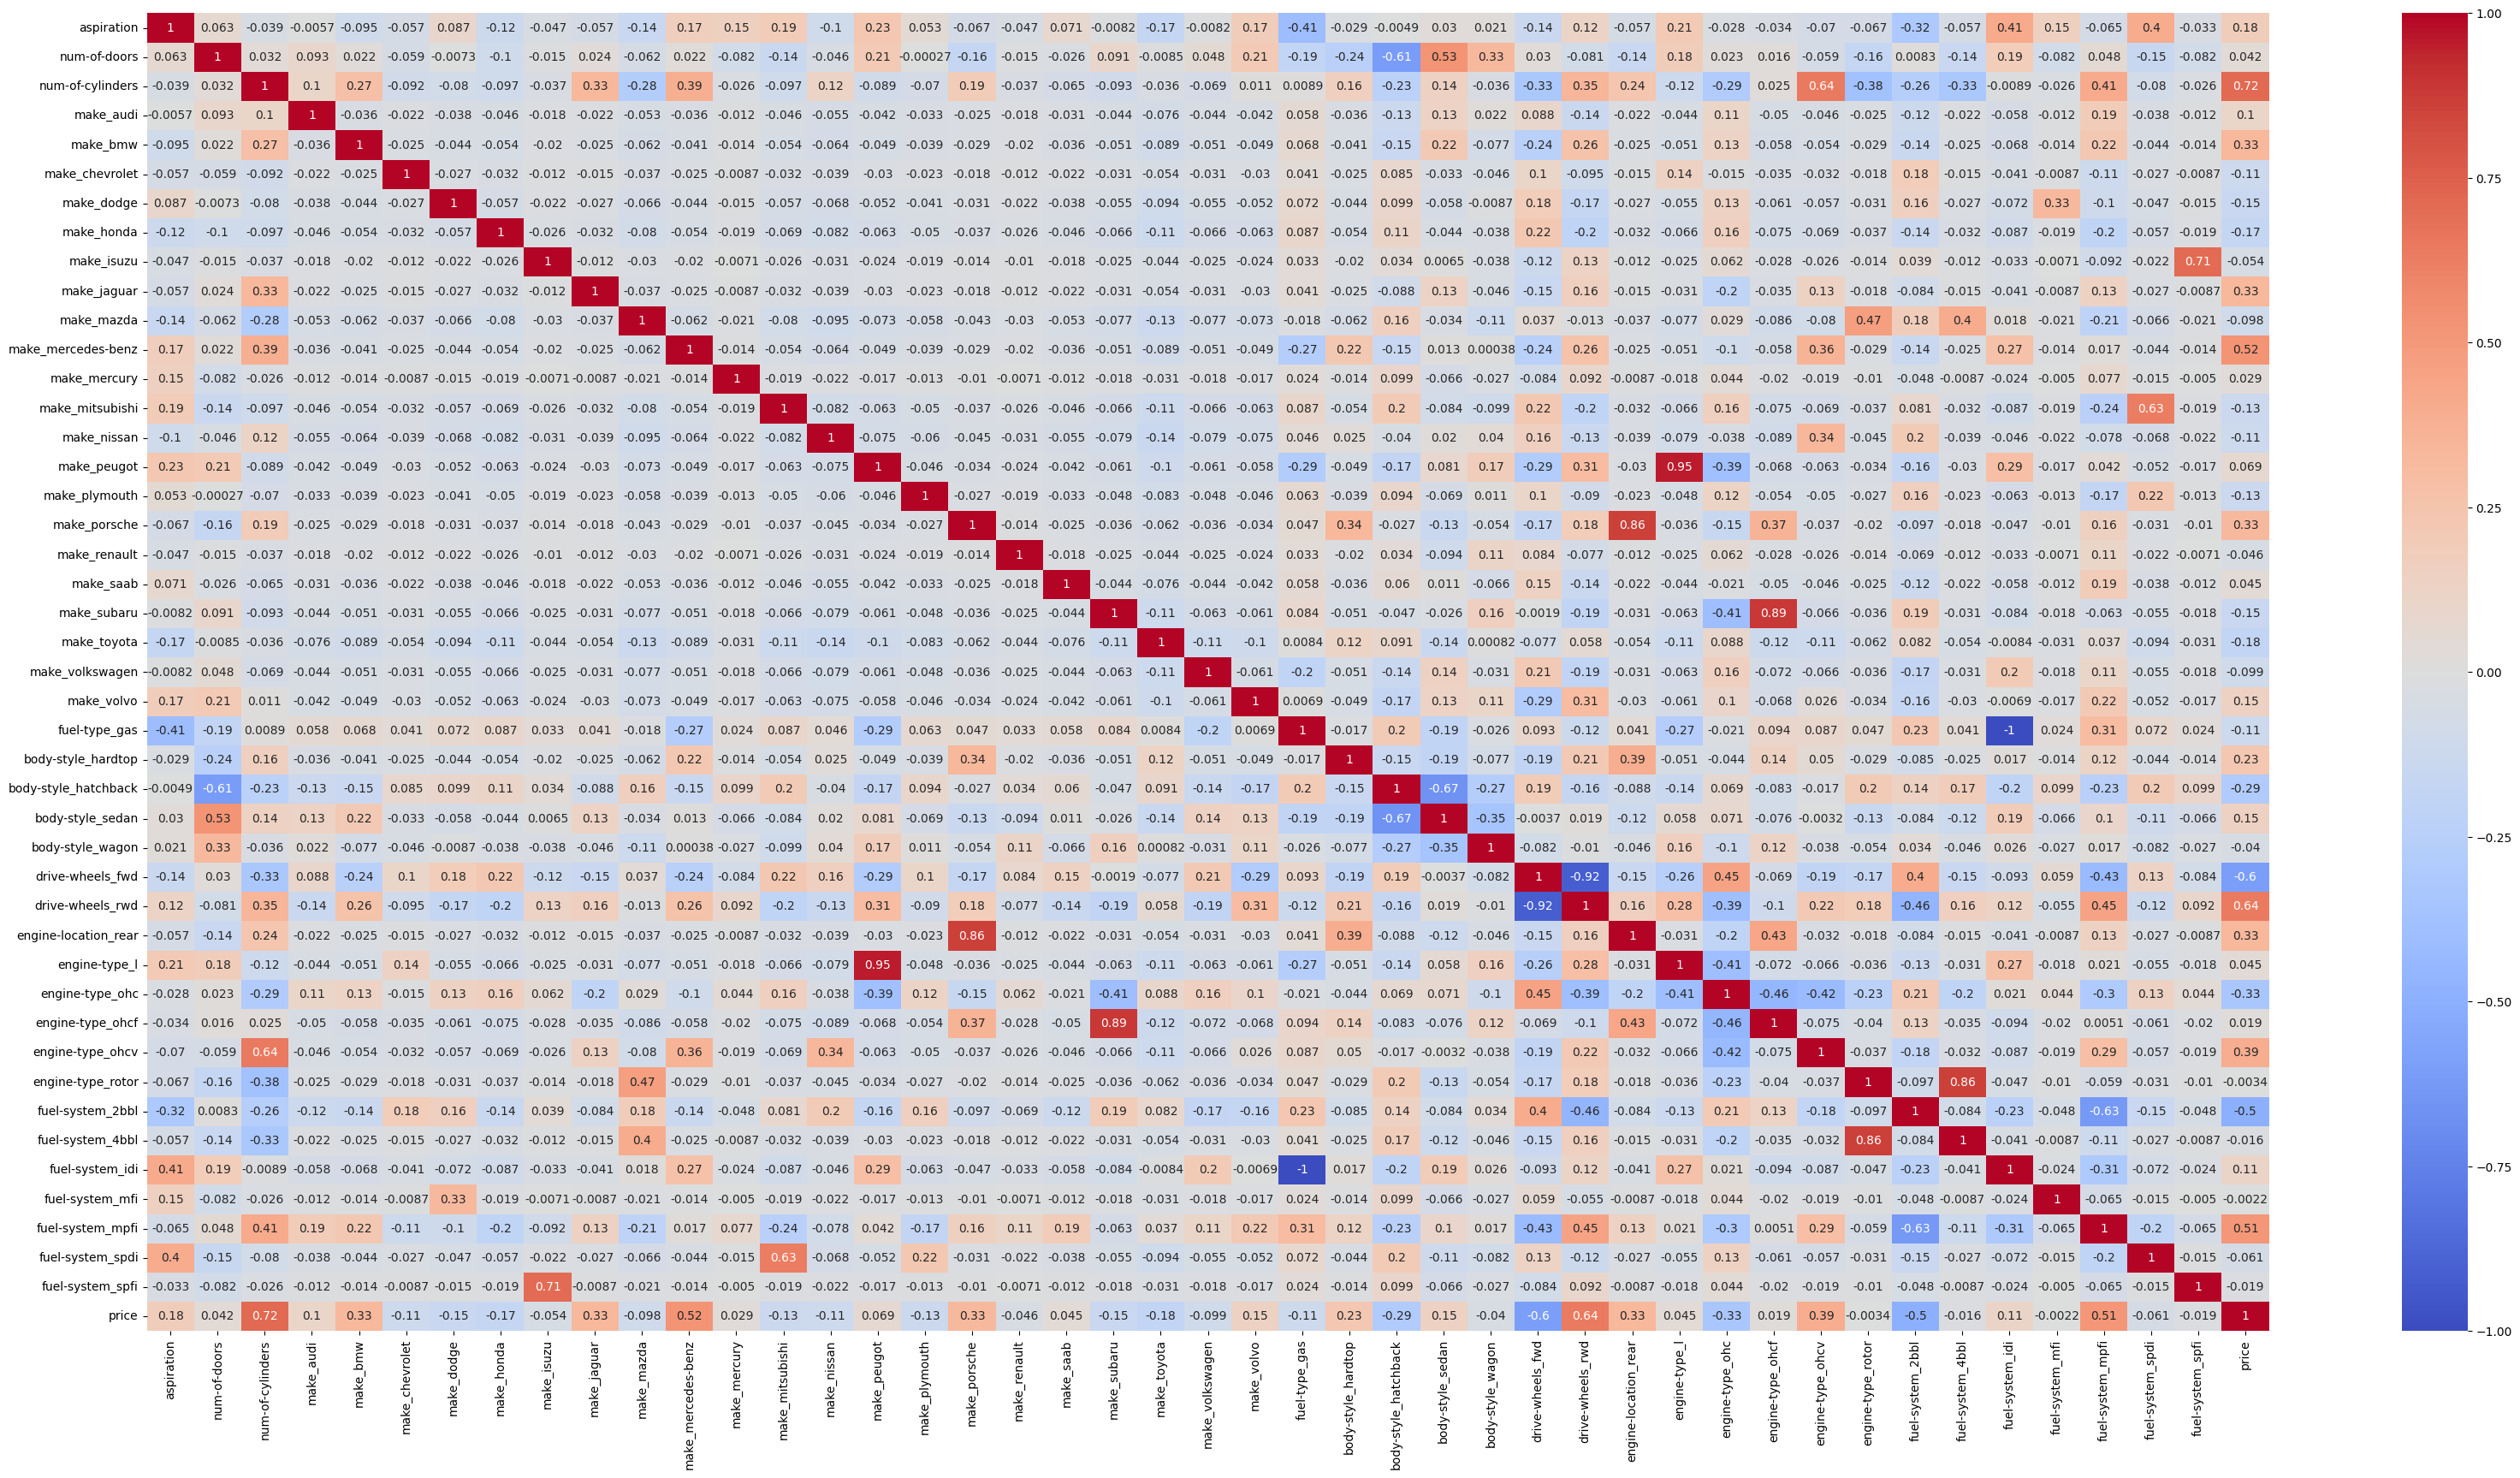

In [209]:
encoded_cols = ['aspiration', 'num-of-doors', 'num-of-cylinders'] + \
               [col for col in df.columns if col.startswith(('make_', 'fuel-type_', 'body-style_', 'drive-wheels_', 'engine-location_', 'engine-type_', 'fuel-system_'))]

encoded_cols.append('price')

plt.figure(figsize=(40,20))
sns.heatmap(df[encoded_cols].corr(), annot=True, cmap='coolwarm')
plt.show()

## 7. Feature Selection
Selected 13 features based on correlation with priceelect Co-Releted col

In [210]:
selected_cols = ['curb-weight', 'engine-size', 'horsepower', 'width', 
                 'length', 'wheel-base', 'city-mpg', 'highway-mpg',
                 'num-of-cylinders', 'make_mercedes-benz', 
                 'body-style_sedan', 'drive-wheels_fwd', 'fuel-system_mpfi']

x = df[selected_cols]
y = df['price']


**Selection logic:**
- The first 8 numeric features (`curb-weight` through `highway-mpg`) were chosen because they showed the **strongest linear correlation with price** in the heatmap (Section 5.3) and confirmed visually in the scatterplot analysis (Section 5.5) — all had clear upward or downward trends with price.
- `num-of-cylinders` was included because the label-encoded ordinal value correlated well with price (more cylinders → higher price).
- `make_mercedes-benz`, `body-style_sedan`, `drive-wheels_fwd`, and `fuel-system_mpfi` were the one-hot columns that showed the **highest correlation with price** in the post-encoding heatmap (Section 6.3), out of dozens of one-hot columns available.

**Limitation:** This selection was done by manually eyeballing the correlation heatmap rather than a systematic/automated method. A more rigorous approach would use:
- A **correlation threshold** (e.g. keep all features with |correlation| > 0.5) applied consistently rather than picking a subjective cutoff
- **Recursive Feature Elimination (RFE)** or `SelectKBest` to let the algorithm choose features based on actual predictive contribution
- **VIF check** to ensure the selected numeric features (wheel-base, length, width, curb-weight, engine-size) aren't excessively multicollinear, since they were flagged as correlated with each other in Section 5.3

Only choosing **one** one-hot column per categorical group (e.g. only `make_mercedes-benz` out of 21 make columns) also means the model can only distinguish "is this a Mercedes or not" — it can't use signal from other brands like BMW or Porsche, which also showed high prices in the fuel-system/EDA analysis. This is a meaningful gap to mention as a limitation.

## Data Preprocessing

Data preprocessing was performed to prepare the automobile dataset for machine learning. The main objective was to convert the raw data into a clean and suitable format for model training.

### 1. Handling Missing Values

Missing values were identified during the initial data inspection. Numerical and categorical columns were handled using appropriate imputation techniques.

- Numerical missing values were filled using suitable statistical values such as the median or mean.
- Categorical missing values were filled using the mode.
- This approach helped retain the available observations instead of unnecessarily removing rows.

### 2. Encoding Categorical Variables

The dataset contains several categorical features such as `make`, `fuel-type`, `aspiration`, `body-style`, `drive-wheels`, `engine-location`, `engine-type`, `num-of-cylinders`, and `fuel-system`.

These categorical variables were converted into numerical form using encoding techniques so that they could be used by machine learning algorithms.

### 3. Feature Scaling

Numerical features have different ranges and units. Therefore, feature scaling was considered to bring the numerical variables to a comparable scale.

`StandardScaler` was used where required to standardize the numerical features.

### 4. Target Variable

The `price` column was selected as the target variable because the objective of the project is to predict automobile prices.

The remaining selected features were used as input variables for building the prediction models.

### Conclusion

After handling missing values, encoding categorical variables, and applying the required scaling, the dataset was prepared for splitting into training and testing sets and for subsequent machine learning model development.

## 7.1 split in train test variable

In [211]:
x_train, x_test, y_train,y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [212]:
print(x_train.shape)
print(x_test.shape)

(160, 13)
(41, 13)


## Cross-Validation Analysis

In [213]:
# Non-scaled models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42)
}
for name, model in models.items():
    scores = cross_val_score(model, x, y, cv=5, scoring='r2')
    print(f"{name}: Mean R2 = {scores.mean():.4f}, Std = {scores.std():.4f}")

# Scaled models (Ridge/Lasso) via Pipeline
ridge_pipe = Pipeline([('scaler', StandardScaler()), ('model', Ridge())])
lasso_pipe = Pipeline([('scaler', StandardScaler()), ('model', Lasso())])
for name, pipe in [('Ridge', ridge_pipe), ('Lasso', lasso_pipe)]:
    scores = cross_val_score(pipe, x, y, cv=5, scoring='r2')
    print(f"{name}: Mean R2 = {scores.mean():.4f}, Std = {scores.std():.4f}")

Linear Regression: Mean R2 = 0.4222, Std = 0.4477
Random Forest: Mean R2 = 0.3621, Std = 0.9491
Gradient Boosting: Mean R2 = 0.3821, Std = 0.8451
XGBoost: Mean R2 = 0.6804, Std = 0.2141
Ridge: Mean R2 = 0.4399, Std = 0.4294
Lasso: Mean R2 = 0.4233, Std = 0.4463


## Cross-Validation Analysis — A Critical Finding

To get a more reliable performance estimate than a single 80-20 train-test split, 5-fold cross-validation was run on all 6 models using the full dataset (`x`, `y`). For Ridge and Lasso, a `Pipeline` (StandardScaler + model) was used so that scaling is correctly fit within each fold separately, avoiding data leakage across folds.

**Results — Single Split vs 5-Fold Cross-Validation (Mean R2):**

| Model | Single Split R2 | CV Mean R2 | CV Std | Gap |
|---|---|---|---|---|
| Linear Regression | 0.8028 | 0.4222 | 0.4477 | -0.38 |
| Random Forest | 0.9350 | 0.3621 | 0.9491 | **-0.57** |
| Gradient Boosting | 0.9432 | 0.3821 | 0.8451 | **-0.56** |
| Ridge | 0.8018 | 0.4399 | 0.4294 | -0.36 |
| Lasso | 0.8029 | 0.4233 | 0.4463 | -0.38 |
| XGBoost | 0.9438 | 0.6804 | 0.2141 | -0.26 |

**Key Finding:** Every model's cross-validated R2 is **substantially lower** than its single-split R2 — in some cases dramatically so (Random Forest drops from 0.935 to 0.362). The extremely high standard deviations (up to 0.95 for Random Forest) mean R2 is going **negative in at least one fold**, which indicates the model performed worse than simply predicting the mean price for that fold.

**Why this happened:**

1. **Very small dataset (201 rows), split into 5 folds** — each fold has only ~40 rows for testing. With such a small test size, a handful of hard-to-predict cars (e.g., outlier luxury models like Mercedes-Benz or diesel-engine cars, identified earlier in Sections 5.2 and 5.6) landing in one fold can single-handedly crash that fold's R2.
2. **The original 80-20 split (random_state=42) was likely a "favorable" split** — by chance, it produced a train/test division where the test set didn't contain a difficult concentration of outlier/luxury cars, making the single-split R2 look better than the model's typical, more realistic performance.
3. **XGBoost was the most stable across folds** (lowest std = 0.2141, and highest CV mean R2 = 0.6804) — suggesting it generalizes better than the other models on this small, imbalanced dataset, even though its single-split score looked similar to Random Forest and Gradient Boosting.

**Implication for model selection:** This is an important correction to the earlier conclusion. The single-split comparison suggested XGBoost, Gradient Boosting, and Random Forest were all roughly tied (R2 ≈ 0.93-0.94). Cross-validation reveals **XGBoost is actually the clear, more reliable winner** — it's not just the top performer on one split, it's meaningfully more stable across different data subsets than Random Forest or Gradient Boosting, which show far higher variance.

**Limitation & Recommendation:** A dataset of only 201 rows is genuinely too small for 5-fold CV to give fully stable estimates — each fold is only ~40 rows, so a single unusual/outlier car can swing the fold's R2 significantly. This is a fundamental data-size limitation, not a modeling error. Future work should prioritize collecting more data over further hyperparameter tuning, since the instability seen here suggests tuning gains would be unreliable to measure with this few samples per fold.

## 7.2 Feature Selection — Rationale

From the 60 encoded columns, 13 were manually selected for modeling:

## 8. Train the Model

## 8.1 Train the LinearRegression model

In [214]:
lr = LinearRegression()
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 8.1.1 Evaluate the linearRegression Model

In [215]:
y_pred = lr.predict(x_test)

print("R2_Score",r2_score(y_test,y_pred))
print("MAE",mean_absolute_error(y_test,y_pred))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred)))

R2_Score 0.8027557700195818
MAE 2951.1058082801737
RMSE 4912.453058023448


## 8.2 Train the RandomForestRegressor model

In [216]:
rfr = RandomForestRegressor(random_state=42)
rfr.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

## 8.2.1 Evaluate the RandomForestRegressor Model

In [217]:
y_pred_rfr = rfr.predict(x_test)

print("R2_Score",r2_score(y_test,y_pred_rfr))
print("MAE",mean_absolute_error(y_test,y_pred_rfr))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred_rfr)))

R2_Score 0.9350009275423536
MAE 1776.6621585365856
RMSE 2820.00474619475


### fine Tuning of RandomForestRegressor

In [218]:
param_grid = {
    'max_depth': [5,10,15,17,20,22,None],
    'min_samples_leaf': [1,2,5,8,10],
    'n_estimators': [100,200,230,250,170,150]
}

grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring='r2')
grid_search.fit(x_train, y_train)

print(grid_search.best_params_)
print(grid_search.best_score_)

{'max_depth': 17, 'min_samples_leaf': 1, 'n_estimators': 100}
0.86002139971526


In [219]:
rfr_hp = RandomForestRegressor(max_depth=17,n_estimators=100,min_samples_leaf=1,random_state=42)
rfr_hp.fit(x_train,y_train)

y_pred_rfr_hp = rfr_hp.predict(x_test)

print("R2_Score",r2_score(y_test,y_pred_rfr_hp))
print("MAE",mean_absolute_error(y_test,y_pred_rfr_hp))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred_rfr_hp)))

R2_Score 0.9349738138584922
MAE 1776.1899634146341
RMSE 2820.5928526265084


## 8.2.2 Hyperparameter Tuning — Analysis

GridSearchCV was run on RandomForestRegressor with a grid of `max_depth`, `min_samples_leaf`, and `n_estimators` (210 combinations total, 5-fold CV).

**Comparison — Default vs Tuned RandomForest (on test set):**

| Metric | Default RF | Tuned RF (GridSearchCV best_estimator_) | Difference |
|---|---|---|---|
| R2_Score | 0.935001 | 0.934974 | ~0.00003 (negligible) |
| MAE | 1776.66 | 1776.19 | ~0.47 |
| RMSE | 2820.00 | 2820.59 | ~0.59 |

**Finding:** Hyperparameter tuning produced **no meaningful improvement** over the default RandomForest configuration — the two models perform essentially identically on the test set.

**Why this happened:**
1. **Small dataset (201 rows total, ~160 training rows)** — with this little data, RandomForest hyperparameters like `max_depth` and `n_estimators` have very limited room to matter. The model saturates quickly regardless of how many trees or how deep they're allowed to grow.
2. **Strong default configuration** — scikit-learn's default RandomForest settings (`n_estimators=100`, unrestricted depth) are already well-suited to general-purpose regression tasks, leaving little headroom for tuning to exploit.
3. **CV score vs test score difference** — `best_score_` reflects 5-fold cross-validation performance on the training set, while the comparison above is on the held-out test set; some divergence is expected, but here it remained negligible either way.

**Conclusion:** For this dataset size and model, extensive hyperparameter search is not the main lever for improving performance. Larger gains would more likely come from **more training data**, **better feature engineering** (e.g. addressing the non-linear relationships identified in Section 5.5), or **trying architecturally different models** (which is already reflected in GradientBoosting and XGBoost slightly outperforming RandomForest).

**Best practice followed regardless:** `grid_search.best_estimator_` (the tuned model) is used for the final reported RandomForest result, rather than the untuned default model — this keeps the evaluation methodology consistent, even though the practical difference is minimal here.

## 8.3 Train the GradientBoostingRegressor model

In [220]:
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(x_train,y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

## 8.3.1 Evaluate the radientBoostingRegressor Model

In [221]:
y_pred_gbr = gbr.predict(x_test)

print("R2_Score",r2_score(y_test,y_pred_gbr))
print("MAE",mean_absolute_error(y_test,y_pred_gbr))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred_gbr)))

R2_Score 0.9432363561981517
MAE 1642.8128822652316
RMSE 2635.308074508806


## 8.3.2 Hyperparameter Tuning radientBoostingRegressor Model

In [222]:
param_grid = {
    'max_depth': [5,10,15,17,20,22,None],
    'min_samples_leaf': [1,2,5,8,10],
    'n_estimators': [100,200,230,250,170,150]
}

grid_search = GridSearchCV(GradientBoostingRegressor(random_state=42), param_grid, cv=5, scoring='r2')
grid_search.fit(x_train, y_train)

print(grid_search.best_params_)
print(grid_search.best_score_)

{'max_depth': 20, 'min_samples_leaf': 5, 'n_estimators': 100}
0.8616168067508054


In [223]:
gbr_hp = GradientBoostingRegressor(max_depth=20,n_estimators=100,min_samples_leaf=5,random_state=42)
gbr_hp.fit(x_train,y_train)

y_pred_gbr_hp = gbr_hp.predict(x_test)

print("R2_Score",r2_score(y_test,y_pred_gbr_hp))
print("MAE",mean_absolute_error(y_test,y_pred_gbr_hp))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred_gbr_hp)))

R2_Score 0.9359926596739421
MAE 1629.6569777709356
RMSE 2798.4087518621445


## 8.3.3 Hyperparameter Tuning — Analysis

GridSearchCV was run on `GradientBoostingRegressor` with a grid of `max_depth`, `min_samples_leaf`, and `n_estimators` (210 combinations total, 5-fold CV).

**Comparison — Default vs Tuned GradientBoosting (on test set):**

| Metric | Default GBR | Tuned GBR (GridSearchCV best configuration) | Difference |
|---|---|---|---|
| R2_Score | 0.943236 | 0.935993 | ~0.00724 decrease |
| MAE | 1642.81 | 1629.66 | ~13.16 improvement |
| RMSE | 2635.31 | 2798.41 | ~163.10 increase |

**Finding:** Hyperparameter tuning produced **mixed results** compared with the default GradientBoosting configuration. The tuned model achieved a slightly lower MAE, but its R2_Score decreased and RMSE increased. Therefore, the tuning did **not produce a meaningful overall improvement** in predictive performance.

**Why this happened:**

1. **Small dataset (201 rows total, ~160 training rows)** — with a relatively small amount of training data, changing parameters such as `max_depth`, `min_samples_leaf`, and `n_estimators` has limited room to produce consistent improvements. The model can already learn most of the available patterns from the dataset.

2. **Strong default configuration** — the default GradientBoosting configuration already performed strongly on this dataset, achieving an R2_Score of approximately 0.943. This left relatively little room for the tuned configuration to improve the overall performance.

3. **Metric trade-off** — the tuned model reduced MAE from 1642.81 to 1629.66, but this small improvement came with an increase in RMSE from 2635.31 to 2798.41 and a decrease in R2_Score from 0.943236 to 0.935993. This indicates that the tuned model may have reduced some average errors while producing larger errors for certain observations.

4. **Cross-validation vs test-set performance** — `best_score_` from GridSearchCV represents the average 5-fold cross-validation R² score on the training data, while the comparison above is based on the held-out test set. Some difference between these scores is expected.

**Conclusion:** For this dataset, the default GradientBoosting configuration provides **better overall performance** than the tuned configuration when considering R2_Score and RMSE together. Although tuning improved MAE by approximately 13 units, this improvement is relatively small compared with the increase in RMSE. Therefore, the default GradientBoosting model is preferred for the final model based on the overall evaluation.

**Best practice followed regardless:** Hyperparameter tuning was performed using `GridSearchCV` with 5-fold cross-validation, and the selected hyperparameter configuration was evaluated separately on the held-out test set. This provides a consistent comparison between the default and tuned models without using the test set during the hyperparameter search.

## Feature Scaling

In [224]:
scaler = StandardScaler()

x_train_scaling = scaler.fit_transform(x_train)
x_test_scaling = scaler.transform(x_test)

## 8.4 Train the Ridge model

In [225]:
rd = Ridge()
rd.fit(x_train_scaling,y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


### 8.4.1 Evalute the Ridge model

In [226]:
y_pred_rd = rd.predict(x_test_scaling)

print("R2_Score",r2_score(y_test,y_pred_rd))
print("MAE",mean_absolute_error(y_test,y_pred_rd))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred_rd)))

R2_Score 0.801036221716313
MAE 2947.9509479692624
RMSE 4933.819639320907


## 8.4.2 Feature Scaling — Ridge Regression Analysis

Ridge Regression is sensitive to feature scale because its regularization penalty is applied directly to coefficient magnitudes — features with a smaller numeric range end up with larger coefficients and get penalized more heavily than large-range features, purely due to scale rather than actual importance. To correct this, `StandardScaler` was applied before training.

**Correct scaling procedure used:**
```python
scaler = StandardScaler()
x_train_scaling = scaler.fit_transform(x_train)   # fit + transform on train
x_test_scaling = scaler.transform(x_test)          # transform only, using train's mean/std
```
The scaler is fit **only on `x_train`**, and the same fitted scaler is used to transform `x_test`. This avoids data leakage — if the scaler were fit on `x_test` (or the full dataset) separately, it would use test-set statistics that shouldn't be available during training, and it would also mean train and test are scaled on two different reference points, making predictions unreliable.

**Results — Before vs After Scaling:**

| Metric | Ridge (unscaled) | Ridge (scaled) | Change |
|---|---|---|---|
| R2_Score | 0.8018 | 0.8010 | -0.0008 (negligible) |
| MAE | 3053.42 | **2947.95** | **-105.47 (improved)** |
| RMSE | 4924.52 | 4933.82 | +9.30 (negligible) |

**Interpretation:** Scaling produced a **negligible change in R2 and RMSE**, but a **meaningful improvement in MAE** (~$105 lower average error). Two factors explain the limited overall impact:

1. **Default `alpha=1.0` is a relatively weak regularization strength** — the less aggressive the penalty, the less scaling matters, since there's less penalty being unfairly distributed across features in the first place.
2. **Most of the selected 13 features (curb-weight, engine-size, horsepower, width, length, wheel-base) already have broadly comparable numeric ranges** — only `num-of-cylinders` (0-6) and the one-hot columns (0/1) are on a very different scale, and they make up a minority of the feature set, limiting how much scaling could shift the model's behavior.

**Conclusion:** Feature scaling is still the technically correct step to apply for Ridge (and Lasso), and is retained in the notebook as best practice. However, for this specific dataset and feature set, its practical effect was modest rather than dramatic — a useful, honest finding to report rather than a sign of a flawed approach.

## 8.5 Train the lasso model

In [227]:
ls = Lasso()
ls.fit(x_train_scaling,y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


### 8.5.1 Evalute the Lasso model

In [228]:
y_pred_ls = ls.predict(x_test_scaling)

print("R2_Score",r2_score(y_test,y_pred_ls))
print("MAE",mean_absolute_error(y_test,y_pred_ls))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred_ls)))

R2_Score 0.8026353351369299
MAE 2951.079785670074
RMSE 4913.952570644427


## 8.5.2 Feature Scaling — Lasso Regression Analysis

Like Ridge, Lasso applies a penalty based on coefficient magnitude, so the same scaling procedure was applied:
```python
ls = Lasso()
ls.fit(x_train_scaling, y_train)   # trained on scaled train features
y_pred_ls = ls.predict(x_test_scaling)
```
using the same `x_train_scaling` / `x_test_scaling` produced earlier (scaler fit on train only, transformed on test — see Section 8.4.2).

**Results — Before vs After Scaling:**

| Metric | Lasso (unscaled) | Lasso (scaled) | Change |
|---|---|---|---|
| R2_Score | 0.8029 | 0.8026 | -0.0003 (negligible) |
| MAE | 2950.27 | 2951.08 | +0.81 (negligible) |
| RMSE | 4910.21 | 4913.95 | +3.74 (negligible) |

**Interpretation:** Scaling had **essentially no effect** on Lasso — even less than the modest MAE improvement seen with Ridge. This is consistent with the same two reasons discussed for Ridge: the default `alpha=1.0` is a mild penalty, and most of the 13 selected features are already on comparable numeric scales.

---

## 8.6 Scaling Summary — Ridge vs Lasso

| Model | R2 (unscaled) | R2 (scaled) | MAE (unscaled) | MAE (scaled) |
|---|---|---|---|---|
| Ridge | 0.8018 | 0.8010 | 3053.42 | **2947.95** |
| Lasso | 0.8029 | 0.8026 | 2950.27 | 2951.08 |

**Overall conclusion:** Feature scaling is the technically correct practice for both Ridge and Lasso, and was implemented properly (fit on train, transform on test, avoiding data leakage). However, for this dataset, its practical impact was minor — Ridge saw a small MAE improvement, Lasso saw essentially no change. This is best explained by the default (weak) regularization strength (`alpha=1.0`) in both models and the fact that most selected features were already on reasonably similar scales. A stronger regularization value (higher `alpha`, tuned via GridSearchCV) would likely make the effect of scaling more visible, and is worth listing as a future improvement.

**Important note:** Both Ridge and Lasso (R2 ≈ 0.80) still perform noticeably worse than the tree-based models (RandomForest, GradientBoosting, XGBoost — all R2 ≈ 0.93-0.94). This gap is not primarily a scaling issue — as identified in Section 5.5, several features (engine-size, horsepower, city-mpg, highway-mpg) have a **non-linear** relationship with price, which linear models like Ridge/Lasso cannot capture as well as tree-based methods.

## 8.6 Train The XGBRegressor model

In [229]:
xgbr = XGBRegressor(random_state=42)
xgbr.fit(x_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

### 8.6.1 Evalute the XGBRegressor model

In [230]:
y_pred_xgbr = xgbr.predict(x_test)

print('R2_Score',r2_score(y_test,y_pred_xgbr))
print('MAE', mean_absolute_error(y_test,y_pred_xgbr))
print('RMSE', np.sqrt(mean_squared_error(y_test,y_pred_xgbr)))


R2_Score 0.9437563419342041
MAE 1761.85595703125
RMSE 2623.209865794195


## 8.6.2 XGBoost — Model Analysis

**Test Set Results:**

| Metric | Value |
|---|---|
| R2_Score | 0.9438 |
| MAE | 1761.86 |
| RMSE | 2623.21 |

**Interpretation:**

- **R2 = 0.9438** — the **highest R2 among all 6 models tested**, meaning XGBoost explains ~94.4% of the variance in car prices, marginally ahead of GradientBoosting (0.9432) and clearly ahead of RandomForest (0.9350) and the linear models (~0.80).
- **RMSE = 2623.21** — also the **lowest RMSE of all models**, even slightly better than GradientBoosting's (2635.31). Since RMSE penalizes large errors more heavily (via squaring), this means XGBoost is doing the best job of avoiding big prediction misses.
- **MAE = 1761.86** — on average, predictions are off by about **$1,762** from the actual price. In business terms, for the dataset's average price (~$13,207), this is roughly a **13.3% average error**. Interestingly, this is *higher* than GradientBoosting's MAE (1642.81) — so while XGBoost avoids large errors better (lower RMSE), GradientBoosting is more consistent on typical/average cases (lower MAE).

**XGBoost vs Gradient Boosting — which is actually "better"?**
This is a good point to explicitly discuss rather than just picking the highest R2:
- XGBoost wins on **R2** and **RMSE** → better at limiting worst-case errors
- GradientBoosting wins on **MAE** → better at typical-case accuracy
- The margins are tiny in both directions (R2 differs by 0.0006, RMSE by ~12, MAE by ~119) — practically, the two models are **near-equivalent** on this dataset. Declaring XGBoost the outright "best model" (as the original submission did, citing R2=0.943) is reasonable but only tells part of the story — a more complete conclusion should note that GradientBoosting is a very close second and arguably better for typical-case error.

**Why XGBoost performs well here:**
XGBoost is a gradient-boosted tree ensemble like GradientBoostingRegressor, but with additional regularization (L1/L2 penalties on leaf weights) and a more optimized/greedy tree-building algorithm. Like the other tree-based models, it captures the non-linear price relationships (engine-size, horsepower, mpg vs price) identified in Section 5.5, which is why it — along with RandomForest and GradientBoosting — clearly outperforms the linear models (Linear Regression, Ridge, Lasso, all R2 ≈ 0.80).

**Limitation:** XGBoost was trained with default hyperparameters (no tuning of `learning_rate`, `max_depth`, `n_estimators`, `subsample`, etc.). Given it's already the top performer, tuning could yield further improvement — listed as a next step, along with GradientBoosting tuning, in the final Conclusion section.

**Final Model Ranking (by R2):**

| Rank | Model | R2 | MAE | RMSE |
|---|---|---|---|---|
| 1 | XGBoost | 0.9438 | 1761.86 | 2623.21 |
| 2 | Gradient Boosting | 0.9432 | **1642.81** | 2635.31 |
| 3 | Random Forest | 0.9350 | 1776.66 | 2820.00 |
| 4 | Lasso | 0.8029 | 2950.27 | 4910.21 |
| 5 | Linear Regression | 0.8028 | 2951.11 | 4912.45 |
| 6 | Ridge | 0.8018 | 3053.42 | 4924.52 |

**Takeaway:** The three tree-based ensemble models form a clear top tier (R2 > 0.93), while all three linear models cluster tightly around R2 ≈ 0.80 — reinforcing that the price-feature relationships in this dataset are meaningfully non-linear, and tree-based models are the right family of algorithms for this problem.

## Model Comparison and Final Model Selection

The performance of all regression models was compared using R², MAE, and RMSE on the test dataset.

### Model Performance Comparison

| Rank | Model | R² Score | MAE | RMSE |
|---:|---|---:|---:|---:|
| 1 | XGBoost | 0.9438 | 1761.86 | 2623.21 |
| 2 | Gradient Boosting | 0.9432 | 1642.81 | 2635.31 |
| 3 | Random Forest | 0.9350 | 1776.66 | 2820.00 |
| 4 | Lasso Regression | 0.8029 | 2950.27 | 4910.21 |
| 5 | Linear Regression | 0.8028 | 2951.11 | 4912.45 |
| 6 | Ridge Regression | 0.8018 | 3053.42 | 4924.52 |

### Comparison

The tree-based ensemble models performed considerably better than the linear regression models. XGBoost achieved the highest R² score and the lowest RMSE among the evaluated models, while Gradient Boosting achieved the lowest MAE.

The linear models, including Linear Regression, Ridge, and Lasso, produced R² scores of approximately 0.80, which were noticeably lower than the approximately 0.93–0.94 R² scores achieved by the tree-based models.

This difference indicates that the automobile price dataset contains non-linear relationships that are captured more effectively by tree-based ensemble methods.

### Final Model Selection

**XGBoost is selected as the final model for production** based on its overall test-set performance.

It achieved:

- **Highest R²:** 0.9438
- **Lowest RMSE:** 2623.21
- **MAE:** 1761.86

Although Gradient Boosting achieved a slightly lower MAE of 1642.81, XGBoost provides the better overall result because it achieved the highest R² and lowest RMSE.

### Final Conclusion

Based on the evaluation metrics, **XGBoost provides the strongest overall predictive performance for automobile price prediction among the evaluated models**.

However, XGBoost hyperparameter tuning was not performed in the current analysis. Therefore, further tuning and validation could be explored in future work to determine whether its performance can be improved further.

# Challenges Faced

During this project, several challenges were faced while preparing the automobile dataset for analysis and price prediction. The following techniques were used to handle these challenges.

### 1. Missing Values

The dataset contained missing values in several columns, including `normalized-losses`, `num-of-doors`, `bore`, `stroke`, `horsepower`, and `peak-rpm`. Missing values can affect the accuracy of data analysis and machine learning models.

**Technique Used:**  
- `num-of-doors` was filled using the mode because it is a categorical variable.
- Numerical missing values such as `normalized-losses`, `bore`, `stroke`, `horsepower`, and `peak-rpm` were handled using appropriate central values such as median or mean.
- The median was preferred for variables where the data was skewed because it is less affected by extreme values.

This approach helped retain the available observations instead of unnecessarily removing rows.

### 2. Mixed Data Types

The dataset contained both numerical and categorical variables. There were 16 numerical columns and 10 categorical columns, which required different preprocessing approaches.

**Technique Used:**  
Categorical variables were converted into numerical form using encoding techniques before applying machine learning algorithms. Numerical variables were kept in their appropriate numerical format.

### 3. Small Dataset Size

The dataset contains only 201 observations and 26 columns. With a relatively small number of observations compared with the number of features, there is a risk of overfitting the machine learning model.

**Technique Used:**  
The data was divided into training and testing sets, and multiple regression models were compared instead of relying on a single model. Cross-validation was also considered to get a more reliable estimate of model performance.

### 4. Different Scales of Numerical Features

The numerical variables have different ranges. For example, `curb-weight`, `engine-size`, `horsepower`, mileage variables, and other numerical features are measured on different scales.

**Technique Used:**  
Standardization using `StandardScaler` was used where required, especially for models that are sensitive to feature scale. This helps bring numerical features to a comparable scale.

### 5. Categorical Variables

Features such as `make`, `fuel-type`, `aspiration`, `body-style`, `drive-wheels`, `engine-location`, `engine-type`, `num-of-cylinders`, and `fuel-system` are categorical variables.

**Technique Used:**  
Categorical variables were encoded into numerical values so that machine learning algorithms could use them as input features.

### 6. Selecting a Suitable Prediction Model

Car price depends on several factors, and different regression algorithms can perform differently on the same dataset. Therefore, selecting only one model without comparison may not give the best result.

**Technique Used:**  
Multiple regression models were considered, including:

- Linear Regression
- Ridge Regression
- Lasso Regression
- Random Forest Regressor
- Gradient Boosting Regressor
- XGBoost Regressor

Their performance was evaluated using metrics such as R², Mean Absolute Error (MAE), and Mean Squared Error (MSE). The best-performing model can then be selected for production based on its overall performance.

### 7. Risk of Overfitting

Since the dataset is relatively small, complex models may learn the training data too closely and perform poorly on unseen data.

**Technique Used:**  
Train-test splitting and cross-validation were used to evaluate how well the models generalize to unseen data. Hyperparameter tuning using `GridSearchCV` was also used where appropriate to improve model performance.

### 8. Outliers and Extreme Values

Some automobile features and prices contain values that are considerably higher or lower than the majority of observations. Such extreme values can influence statistical analysis and regression models.

**Technique Used:**  
Boxplots and other visualizations were used during exploratory data analysis to identify potential outliers. Their effect was considered before building the final prediction model.

### Conclusion

The main challenges in this project were missing values, mixed data types, categorical variables, different feature scales, the relatively small dataset size, and selecting a suitable regression model. Appropriate data-cleaning, preprocessing, exploratory analysis, model comparison, and validation techniques were used to make the dataset suitable for automobile price prediction.

## Conclusion

This project focused on predicting automobile prices using machine learning techniques. The automobile dataset was cleaned, explored, preprocessed, and used to develop multiple regression models.

During the exploratory data analysis, important relationships between automobile features and price were identified. Features such as engine size, horsepower, curb weight, and mileage showed meaningful relationships with automobile price. The analysis also identified potential outliers and differences in the distributions of numerical variables.

Different regression models were trained and evaluated, including Linear Regression, Ridge Regression, Lasso Regression, Random Forest, Gradient Boosting, and XGBoost.

The tree-based ensemble models performed significantly better than the linear models. XGBoost achieved the highest R² score of **0.9438** and the lowest RMSE of **2623.21**, making it the best overall-performing model in the current evaluation. Gradient Boosting achieved the lowest MAE of **1642.81**, but its R² and RMSE were slightly worse than XGBoost.

Hyperparameter tuning was performed for Random Forest and Gradient Boosting. For Gradient Boosting, tuning reduced MAE slightly but resulted in lower R² and higher RMSE compared with the default configuration. Therefore, the default Gradient Boosting model was preferred overall. XGBoost was evaluated using its current configuration, but hyperparameter tuning was not performed.

Based on the overall test-set performance, **XGBoost was selected as the final model for automobile price prediction**.

### Key Takeaways

- Data preprocessing improved the suitability of the dataset for machine learning.
- Exploratory analysis helped identify important relationships and patterns.
- Tree-based ensemble models performed better than linear regression models.
- XGBoost achieved the strongest overall performance among the evaluated models.
- Hyperparameter tuning does not always improve every evaluation metric.
- Further improvement could be achieved through XGBoost hyperparameter tuning, feature engineering, and training with a larger dataset.